#**Regresión — Flight Price Prediction**

## **Integrantes:**

* Mariamny Del Valle Ramírez Telles
* David Alejandro Gutiérrez Leal
* Sahian Salomé Gutiérrez Ossa


**Link Dataset:**
https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction

# **Fase 1 — EDA, limpieza y preprocesamiento (aplica a ambos datasets)**

###Punto 1:
Lea la documentación de cada dataset y describa el problema de negocio/salud que representa, e identifique cuál es la
variable objetivo (target) en cada caso.

El dataset busca analizar los precios de los vuelos y entender cómo diferentes características del viaje pueden influir en el costo de un tiquete. La idea es utilizar información como la aerolínea, las ciudades de origen y destino, los horarios, el número de escalas, la clase, la duración del vuelo y los días de anticipación para predecir el precio del tiquete.

Por lo tanto, la variable objetivo (target) es price, ya que es el valor que queremos que el modelo aprenda a predecir. Al ser un valor numérico continuo, el problema corresponde a un modelo de regresión.

###Punto 2:
Cargue el dataset con pandas, muestre head()/tail(), .shape y .info(). Construya el diccionario de datos (columna, tipo
esperado, significado).

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.base import clone
from sklearn.svm import SVR
import time

In [3]:
# Set the path to the file you'd like to load
file_path = "Clean_Dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shubhambathwal/flight-price-prediction",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documentation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_1350/3310387982.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'flight-price-prediction' dataset.


In [4]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
df.tail()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [6]:
df.shape

(300153, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


# Diccionario de Datos — Flight Price Prediction

| # | Columna | Tipo (pandas) | Tipo esperado | Significado |
|---|---------|---------------|---------------|-------------|
| 0 | Unnamed: 0 | int64 | — (índice) | Índice residual del CSV original; no aporta información, se eliminará |
| 1 | airline | object | Categórico nominal | Aerolínea que opera el vuelo (6 categorías) |
| 2 | flight | object | Categórico nominal (alta cardinalidad) | Código del vuelo (identificador, no predictivo) |
| 3 | source_city | object | Categórico nominal | Ciudad de origen (6 ciudades) |
| 4 | departure_time | object | Categórico ordinal/nominal | Franja horaria de salida (ej. Morning, Evening, Night) |
| 5 | stops | object | Categórico ordinal | Número de escalas (zero, one, two_or_more) |
| 6 | arrival_time | object | Categórico ordinal/nominal | Franja horaria de llegada |
| 7 | destination_city | object | Categórico nominal | Ciudad de destino (6 ciudades) |
| 8 | class | object | Categórico binario/nominal | Clase del asiento (Economy, Business) |
| 9 | duration | float64 | Numérico continuo | Duración total del viaje en horas |
| 10 | days_left | int64 | Numérico discreto | Días entre la fecha de compra y la fecha del vuelo |
| 11 | price | int64 | Numérico continuo (target) | Precio del tiquete — **variable objetivo** |

**Notas generales**
- El dataset tiene 300,153 registros y 12 columnas, sin valores nulos (`Non-Null Count` = 300153 en todas).
- `Unnamed: 0` es un artefacto del CSV (índice duplicado) hay que eliminarlo en la fase de limpieza.
- `flight` tiene demasiadas categorías únicas; tenemos que evaluar si se descarta o se codifica distinto.
- `stops`, `departure_time` y `arrival_time` tienen orden natural implícito, a definir como Ordinal vs One-Hot.

### Punto 3:
.describe() para las columnas numéricas. Interprete al menos 3 estadísticos por dataset en términos del problema.

In [8]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


1)En la duración de los vuelos, la media es de 12.22 horas, mientras que la mediana es de 11.25. Como son valores relativamente cercanos, la distribución no está demasiado sesgada, aunque hay un ligero sesgo hacia la derecha, probablemente por algunos vuelos que duran bastante más que la mayoría.

Además, la desviación estándar es de 7.19 horas, lo que nos indica que hay bastante variación en la duración de los vuelos.

2)Para los días de anticipación, la media y la mediana son prácticamente iguales, ambas alrededor de 26 días. Esto nos indica que los datos están bastante equilibrados y no presentan un sesgo importante.

3)En el precio encontramos algo diferente. La media es de aproximadamente 20.890, pero la mediana es de solo 7.425. Esta diferencia tan grande indica que los datos están fuertemente sesgados hacia la derecha.

Esto significa que la mayoría de los tiquetes tienen precios relativamente bajos, pero existe un grupo de tiquetes mucho más caros que hace que el promedio aumente bastante.

Además, la desviación estándar es de aproximadamente 22.698, lo que confirma que los precios tienen una dispersión bastante alta.

###Punto 4:
 Identifique valores nulos por columna, calcule su porcentaje, y proponga una estrategia de imputación o eliminación. Justifique la elección según el porcentaje de nulos y el tipo de variable (¿es razonable imputar con la media? ¿con la moda? ¿es mejor eliminar la fila o la columna?).

In [9]:
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

null_info = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percentages
})

null_info

,Null Count,Null Percentage
Unnamed: 0,0,0.0
airline,0,0.0
flight,0,0.0
source_city,0,0.0
departure_time,0,0.0
stops,0,0.0
arrival_time,0,0.0
destination_city,0,0.0
class,0,0.0
duration,0,0.0


Como se observa en el resultado anterior y se confirmó previamente con df.info(), el dataset no presenta valores nulos en ninguna de sus 12 columnas (0.0% en todas). Por lo tanto, no es necesario aplicar ninguna estrategia de imputación o eliminación de nulos en esta fase.

###Punto 5:
Identifique y elimine duplicados si existen. Reporte cuántos se eliminaron.

In [10]:
df_no_index = df.drop(columns=['Unnamed: 0'])

num_duplicates = df_no_index.duplicated().sum()
print(f"Número de filas duplicadas encontradas: {num_duplicates}")

if num_duplicates > 0:
    df_cleaned = df_no_index.drop_duplicates().reset_index(drop=True)
    print(f"Se eliminaron {num_duplicates} filas duplicadas.")
    print(f"Nueva forma del DataFrame: {df_cleaned.shape}")
else:
    df_cleaned = df_no_index.copy() # Crear una copia para mantener la coherencia en la nomenclatura de las variables.
    print("No se encontraron filas duplicadas.")

df_cleaned.head()

Número de filas duplicadas encontradas: 0
No se encontraron filas duplicadas.


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Al revisar los registros duplicados con df.duplicated(), encontramos 0 filas duplicadas. Es decir, no hay registros que estén completamente repetidos en el dataset.

###Punto 6
Revise inconsistencias de formato en columnas categóricas o de texto (mayúsculas/minúsculas, espacios, etiquetas
equivalentes) y corríjalas

In [11]:
print('Columnas categóricas (tipo object) y sus valores únicos:')
for col in df_cleaned.select_dtypes(include='object').columns:
    n_unique = df_cleaned[col].nunique()
    print(f"\nColumna '{col}' ({n_unique} valores únicos):")
    if n_unique <= 15:
        print(df_cleaned[col].unique())
    else:
        print(f"Demasiados valores únicos para mostrar (ej: {df_cleaned[col].unique()[:5]}...)")

# Verificación de espacios extra
print("\n--- Verificación de espacios extra ---")
inconsistencias_encontradas = False
for col in df_cleaned.select_dtypes(include='object').columns:
    valores = df_cleaned[col].unique()
    con_espacios = [v for v in valores if v != v.strip()]
    if con_espacios:
        inconsistencias_encontradas = True
        print(f"Columna '{col}' tiene valores con espacios extra: {con_espacios}")

if not inconsistencias_encontradas:
    print("No se encontraron valores con espacios extra en ninguna columna.")

print("\nVerificación completada.")

Columnas categóricas (tipo object) y sus valores únicos:

Columna 'airline' (6 valores únicos):
['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']

Columna 'flight' (1561 valores únicos):
Demasiados valores únicos para mostrar (ej: ['SG-8709' 'SG-8157' 'I5-764' 'UK-995' 'UK-963']...)

Columna 'source_city' (6 valores únicos):
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']

Columna 'departure_time' (6 valores únicos):
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']

Columna 'stops' (3 valores únicos):
['zero' 'one' 'two_or_more']

Columna 'arrival_time' (6 valores únicos):
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']

Columna 'destination_city' (6 valores únicos):
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']

Columna 'class' (2 valores únicos):
['Economy' 'Business']

--- Verificación de espacios extra ---
No se encontraron valores con espacios extra en ninguna columna.

Verificación complet

Al revisar los valores únicos de las columnas categóricas, no se observan inconsistencias obvias como diferentes usos de mayúsculas/minúsculas para la misma categoría, espacios extra o etiquetas equivalentes que necesiten unificación. Los valores parecen estar limpios y bien definidos para cada categoría.

###Punto 7
Identifique outliers en al menos dos columnas numéricas relevantes usando el criterio IQR. Repórtelos y decida si se tratan o se documentan sin eliminar, justificando la decisión (¿tienen sentido de negocio, como vuelos de última hora muy caros, o son errores de captura?).

In [12]:
# Identificar columnas numéricas
numeric_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
print(f"Columnas numéricas identificadas: {list(numeric_cols)}")

outliers_summary = {}

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outliers_summary[col] = len(outliers)

    print(f"\nOutliers en la columna '{col}':")
    print(f"Límites IQR: [{lower_bound:.2f}, {upper_bound:.2f}]")
    if not outliers.empty:
        print(f"Se encontraron {len(outliers)} outliers en '{col}' ({len(outliers)/len(df_cleaned)*100:.2f}% del total).")
    else:
        print(f"No se encontraron outliers en la columna '{col}' usando el criterio IQR.")

print("\nResumen de outliers por columna:", outliers_summary)

Columnas numéricas identificadas: ['duration', 'days_left', 'price']

Outliers en la columna 'duration':
Límites IQR: [-7.18, 30.18]
Se encontraron 2110 outliers en 'duration' (0.70% del total).

Outliers en la columna 'days_left':
Límites IQR: [-19.50, 72.50]
No se encontraron outliers en la columna 'days_left' usando el criterio IQR.

Outliers en la columna 'price':
Límites IQR: [-51824.00, 99128.00]
Se encontraron 123 outliers en 'price' (0.04% del total).

Resumen de outliers por columna: {'duration': 2110, 'days_left': 0, 'price': 123}


Decisión: Los outliers de duration y price se documentan, pero no se eliminan. No parecen errores de captura, ya que tienen una explicación razonable dentro del contexto de los vuelos: duraciones muy altas pueden deberse a múltiples escalas y tiempos de espera, mientras que precios muy altos pueden corresponder a vuelos Business o compras de última hora. Eliminarlos podría hacer que el modelo perdiera información sobre casos reales y extremos del negocio.

En days_left no hay outliers, por lo que no requiere tratamiento.

### Punto 8
Genere las gráficas de EDA (barras, pie, histograma, scatter plot y boxplot) para las variables relevantes de cada
dataset. Para cada gráfica incluya el código, la imagen y un párrafo de interpretación con una recomendación como
responsable de la toma de decisiones.

/tmp/ipykernel_1350/3731605584.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='airline', data=df_cleaned, order=df_cleaned['airline'].value_counts().index, palette='viridis')


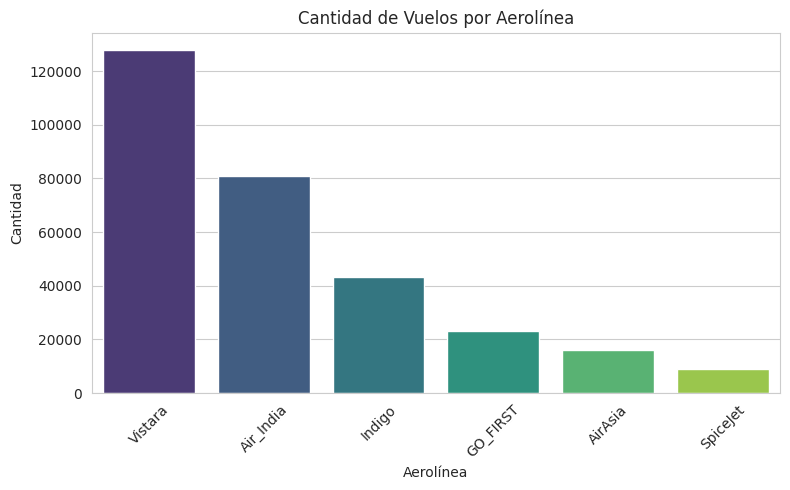

In [13]:
# Estilo de plots
sns.set_style("whitegrid")

# Cantidad de Vuelos por Aerolínea
plt.figure(figsize=(8, 5))
sns.countplot(x='airline', data=df_cleaned, order=df_cleaned['airline'].value_counts().index, palette='viridis')
plt.title('Cantidad de Vuelos por Aerolínea')
plt.xlabel('Aerolínea')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretación y Recomendación (Aerolínea)

**Interpretación:** La gráfica de barras muestra la cantidad de vuelos por aerolínea en el dataset. Vistara domina claramente con más de 120,000 vuelos, seguida por Air_India (80,000). El resto de aerolíneas (Indigo, GO_FIRST, AirAsia, SpiceJet) tienen una participación considerablemente menor, con SpiceJet como la de menor presencia (~9,000 vuelos). Existe un desbalance notable en la representación de las aerolíneas dentro del dataset.

**Recomendación:** Este desbalance debe tenerse en cuenta en la fase de encoding: con solo 6 categorías, un One-Hot Encoding es perfectamente viable, pero conviene monitorear si el modelo aprende patrones robustos para las aerolíneas con pocos registros (SpiceJet, AirAsia) o si su influencia en el precio queda subrepresentada. Como responsable de la toma de decisiones, valdría la pena cruzar esta variable con price y class más adelante, ya que la dominancia de Vistara y Air_India podría estar asociada a que ofrecen más opciones en clase Business, lo cual impactaría directamente las predicciones de precio.

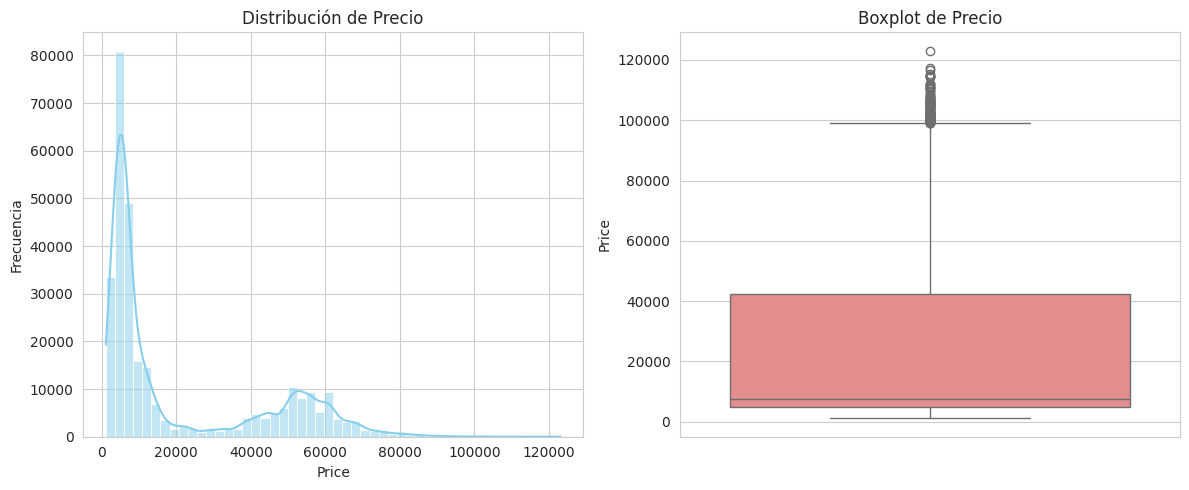

In [14]:
# Distribución de precio
plt.figure(figsize=(12, 5))

# Histograma

plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribución de Precio')
plt.xlabel('Price')
plt.ylabel('Frecuencia')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['price'], color='lightcoral')
plt.title('Boxplot de Precio')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

### Interpretación y Recomendación (Distribución de Price)

**Interpretación:** El histograma confirma visualmente lo observado en el Punto 3 y 7: la distribución de price es bimodal y con fuerte sesgo a la derecha, esto se confirma comparando la media (20,889.66) con la mediana (7,425): al ser la media considerablemente mayor que la mediana, la cola larga de la distribución se extiende hacia la derecha (valores altos). Hay un primer y gran pico concentrado en precios bajos (~5,000–10,000), correspondiente a la mayoría de los tiquetes Economy, y un segundo pico más pequeño alrededor de 50,000–60,000, correspondiente a los tiquetes Business. El boxplot refuerza esto: la mediana está muy cerca del piso con la caja comprimida hacia abajo, mientras que la larga cola de puntos por encima de ~99,000 corresponde a los 123 outliers identificados en el Punto 7 (probablemente Business en rutas largas o compras de último momento).

**Recomendación:** Como responsable de la toma de decisiones, esta bimodalidad es la señal más importante del EDA hasta ahora: sugiere que price está siendo dirigido en gran parte por una variable categórica subyacente (class), más que por una tendencia continua. Se recomienda verificar esta hipótesis separando el histograma por class en el siguiente análisis, y considerar una transformación logarítmica de price (log(price)) antes de modelar, ya que reduce la asimetría y ayuda a que modelos lineales (Regresión Lineal, Ridge) no se vean dominados por los valores extremos de Business. Para modelos basados en árboles (Random Forest, Gradient Boosting), esta transformación es menos crítica, pero sigue siendo útil para la evaluación de residuos.

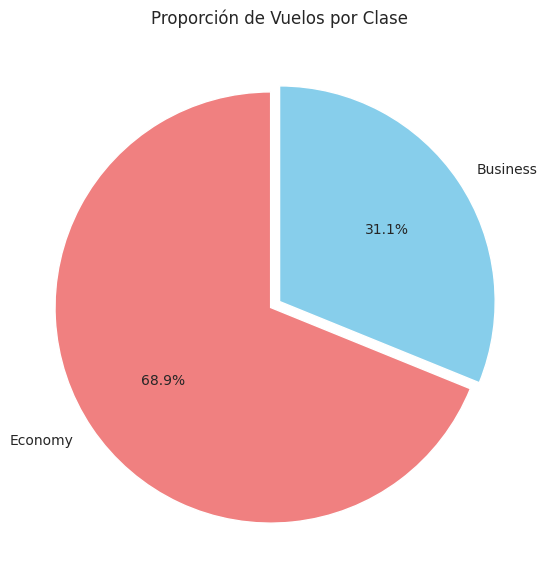

In [15]:
# Proporción de Vuelos por Clase
plt.figure(figsize=(7, 7))
df_cleaned['class'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90,
    colors=['lightcoral', 'skyblue'], explode=[0.05, 0]
)
plt.title('Proporción de Vuelos por Clase')
plt.ylabel('')
plt.show()

### Interpretación y Recomendación (Proporción por Clase)

**Interpretación:** El gráfico de pastel confirma que el dataset está dominado por tiquetes Economy (68.9%), mientras que Business representa solo el 31.1% de los vuelos. Este desbalance conecta directamente con lo observado en el histograma de price (Punto 8, gráfica 2): el pico dominante en precios bajos corresponde a ese ~69% de registros Economy, mientras que el segundo pico, más pequeño, corresponde al ~31% de Business confirmando visualmente que la bimodalidad de price está impulsada por esta variable.

**Recomendación:** Como responsable de la toma de decisiones, este 31% de Business no es un caso marginal ni un outlier a ignorar es un segmento de mercado sustancial que el modelo debe aprender a predecir bien, no solo el promedio general. Se recomienda evaluar el error del modelo por separado en cada clase (ej. RMSE/MAE calculado únicamente sobre las filas de Business vs únicamente sobre Economy) en la fase de evaluación, ya que un buen desempeño agregado podría estar ocultando un mal ajuste específico en el segmento Business, que es precisamente el más valioso en términos de ingreso por tiquete. Asimismo, class debería tratarse como una de las variables más importantes en el encoding (Punto 9), dado su fuerte poder explicativo sobre price.

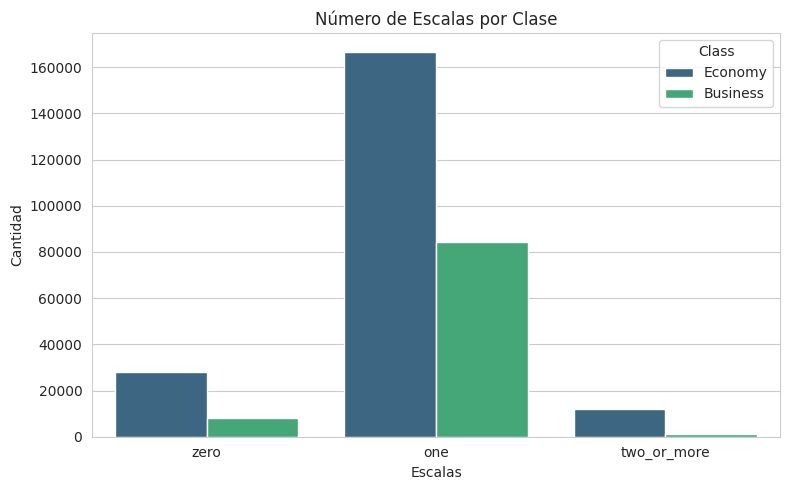

In [16]:
# Escalas por Clase
plt.figure(figsize=(8, 5))
sns.countplot(x='stops', hue='class', data=df_cleaned, order=['zero','one','two_or_more'], palette='viridis')
plt.title('Número de Escalas por Clase')
plt.xlabel('Escalas')
plt.ylabel('Cantidad')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

### Interpretación y Recomendación (Escalas por Clase)

**Interpretación:** La gran mayoría de los vuelos, tanto Economy como Business, tienen una escala ("one"), siendo la categoría dominante en ambas clases. Los vuelos directos ("zero") y con dos o más escalas ("two_or_more") son considerablemente menos frecuentes en ambas clases. Se observa que la proporción relativa entre categorías de escalas es similar para Economy y Business es decir, no parece haber una relación fuerte entre el número de escalas y la clase del tiquete; ambas siguen un patrón parecido, solo que Economy tiene mayor volumen total.

**Recomendación:** Como responsable de la toma de decisiones, esto sugiere que stops y class aportan información relativamente independiente al modelo no son redundantes entre sí, por lo que ambas variables deben conservarse en el modelo de regresión. Sin embargo, vale la pena notar que la categoría "two_or_more" tiene muy pocos registros en Business (apenas visible en la gráfica), lo que podría generar estimaciones menos confiables del modelo para esa combinación específica; se recomienda revisar el desempeño del modelo en ese subgrupo particular durante la validación, en vez de asumir que el error promedio general aplica por igual a todas las combinaciones de stops y class.

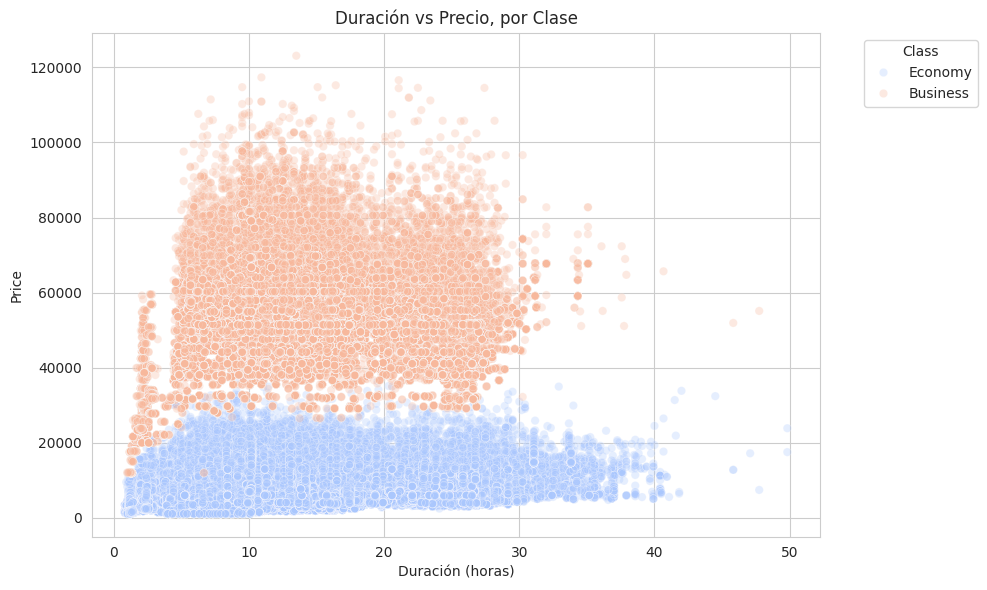

In [17]:
# Duración vs Precio, por Clase
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration', y='price', hue='class', data=df_cleaned, alpha=0.3, palette='coolwarm')
plt.title('Duración vs Precio, por Clase')
plt.xlabel('Duración (horas)')
plt.ylabel('Price')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Interpretación y Recomendación (Duración vs Precio, por Clase)

**Interpretación:** Esta gráfica confirma visualmente la hipótesis planteada en la gráfica 2, la separación entre Economy (azul) y Business (naranja) es prácticamente perfecta, con dos bandas horizontales bien diferenciadas y muy poco solapamiento entre ellas. Dentro de cada clase, sin embargo, duration no muestra una relación lineal clara con price la nube de puntos es ancha y dispersa en el eje horizontal para cualquier nivel de precio dado, tanto en Economy como en Business. Esto significa que la duración del vuelo, por sí sola, tiene poco poder predictivo sobre el precio; es class la que domina completamente la posición vertical (el nivel de precio).

**Recomendación:** Como responsable de la toma de decisiones, esta gráfica es evidencia clara de que un modelo de regresión que use únicamente duration como predictor tendría un desempeño pobre (R² bajo), mientras que incluir class sería determinante para la capacidad predictiva del modelo. Se recomienda priorizar class como variable de mayor peso esperado, y considerar duration como una variable secundaria/de ajuste fino, más útil en combinación con otras (como stops o airline) que de forma aislada. Este patrón también sugiere que modelos capaces de capturar interacciones (Random Forest, Gradient Boosting) podrían aprovechar mejor esta relación no lineal entre variables que un modelo puramente lineal sin términos de interacción explícitos.

/tmp/ipykernel_1350/1957277162.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='price', data=df_cleaned, palette='coolwarm', showfliers=False)


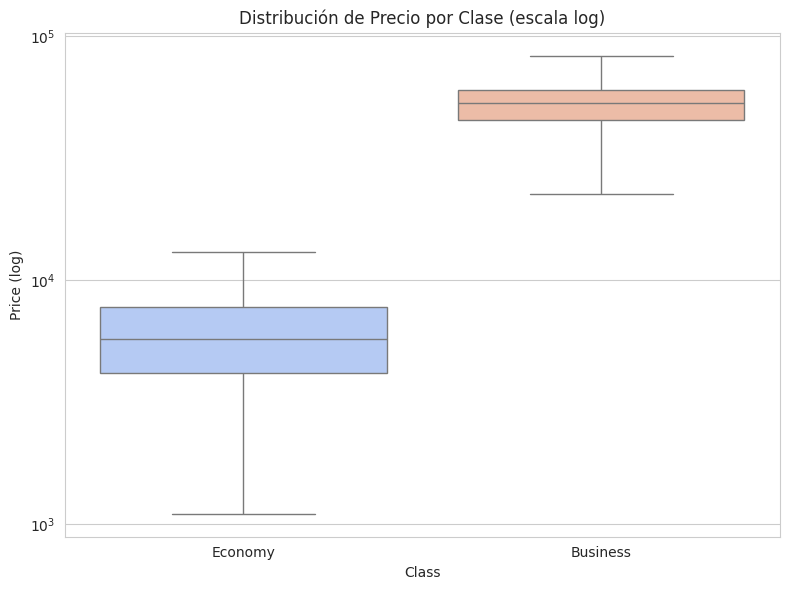

In [18]:
# precio por clase
plt.figure(figsize=(8, 6))
sns.boxplot(x='class', y='price', data=df_cleaned, palette='coolwarm', showfliers=False)
plt.yscale('log')
plt.title('Distribución de Precio por Clase (escala log)')
plt.xlabel('Class')
plt.ylabel('Price (log)')
plt.tight_layout()
plt.show()

### Interpretación y Recomendación (Distribución de Precio por Clase, escala log)

**Interpretación:** Al usar escala logarítmica en el eje Y, se elimina la distorsión visual que antes causaba la asimetría extrema de price, permitiendo comparar limpiamente ambas cajas. Se confirma una separación total y sin solapamiento entre las dos clases: incluso el precio máximo de Economy (12,000) queda muy por debajo del mínimo de Business (~23,000). La caja de Business también es visiblemente más ancha en términos relativos, lo que indica mayor variabilidad de precios dentro de ese segmento probablemente por la combinación de rutas cortas/largas y distintos niveles de anticipación de compra mientras que Economy es más homogéneo y consistente en su rango de precios.

**Recomendación:** Como responsable de la toma de decisiones, esta separación absoluta (0% de solapamiento) confirma que class es, con alta probabilidad, la variable más importante del modelo, tan determinante que casi podría funcionar como un "primer filtro" antes de refinar la predicción con las demás variables. Dado que Business muestra mayor dispersión interna, se recomienda que el equipo de modelado preste especial atención a la calidad de las predicciones dentro de ese segmento (por ejemplo, revisando si el error del modelo es mayor ahí que en Economy), ya que es un segmento con más variabilidad por explicar y, al mismo tiempo, el de mayor valor económico por transacción.

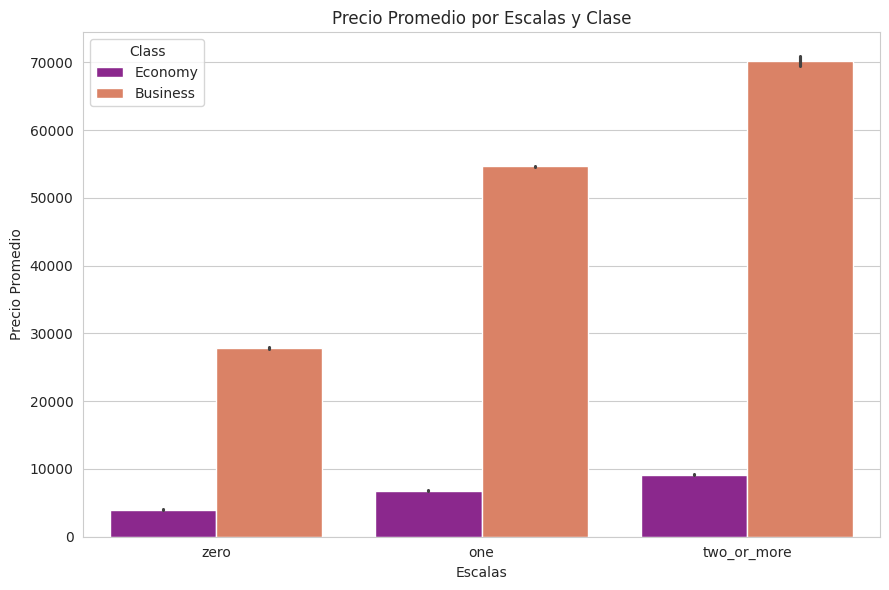

In [19]:
# Precio promedio por número de escalas y clase
plt.figure(figsize=(9, 6))
sns.barplot(x='stops', y='price', hue='class', data=df_cleaned, order=['zero','one','two_or_more'], palette='plasma', estimator='mean')
plt.title('Precio Promedio por Escalas y Clase')
plt.xlabel('Escalas')
plt.ylabel('Precio Promedio')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

### Interpretación y Recomendación (Precio Promedio por Escalas y Clase)

**Interpretación:** Esta gráfica revela un patrón que las anteriores no habían mostrado: dentro de cada clase por separado, el precio promedio aumenta consistentemente con el número de escalas. En Economy, sube de ~4,000 (zero) a ~6,700 (one) y ~9,000 (two or more). En Business, el aumento es mucho más marcado: de ~28,000 (zero) a ~54,500 (one) y ~70,000 (two_or_more) más del doble entre vuelos directos y de dos o más escalas. Esto contrasta con lo observado en el scatter (gráfica 5), donde duration sola no mostraba relación clara con price; aquí se ve que stops sí tiene una relación positiva clara y consistente dentro de cada clase.

**Recomendación:** Como responsable de la toma de decisiones, esta es una señal importante para el modelado: stops no es redundante con class (como ya se sospechaba en la gráfica 4) y aporta información predictiva propia y consistente, especialmente valiosa en Business, donde el efecto es más pronunciado (posiblemente por mayor tiempo total de viaje, comidas a bordo en escalas, o rutas con menos disponibilidad directa). Se recomienda incluir explícitamente la interacción stops × class en el modelo ya sea mediante variables de interacción para modelos lineales, o confiando en que modelos de árboles (Random Forest, Gradient Boosting) la capturen automáticamente en lugar de tratar ambas variables como completamente independientes entre sí.

### Punto 9

Para cada variable categórica, decida y justifique la técnica de codificación apropiada (One-Hot, Ordinal o Binary
Encoding), considerando si la variable tiene orden natural, su cardinalidad, y qué algoritmos se van a usar (recuerde que
Label/Ordinal Encoding puede introducir un orden falso en modelos lineales o de distancia)

**1. Variables categóricas binarias**

La variable `class` es binaria, ya que solamente tiene dos categorías posibles (`Economy`/`Business`).

Para esta variable se utilizará una **codificación binaria**, asignando valores de 0 y 1 a cada categoría. Esto es equivalente a utilizar Label Encoding. En este caso no hay problema de crear un orden falso, porque solamente existen dos categorías y la asignación de 0 y 1 no representa una jerarquía entre ellas.

Además, esta codificación permite trabajar con una sola columna, en lugar de crear varias columnas como ocurriría con One-Hot Encoding. Esto es especialmente relevante aquí porque, como se vio en el EDA (Punto 8), `class` es la variable con mayor poder explicativo sobre `price` mantenerla en una sola columna numérica facilita interpretar directamente su coeficiente en modelos lineales.

**2. Variables categóricas ordinales**

Las variables `stops`, `departure_time` y `arrival_time` se consideran variables ordinales porque sus categorías tienen un **orden natural e interpretable en el contexto del problema**.

Por ejemplo, en `stops` existe una progresión clara: `zero < one < two_or_more`, que además demostró tener una relación consistente con `price` en el EDA (Punto 8, gráfica 7: a más escalas, mayor precio promedio, tanto en Economy como en Business). En `departure_time` y `arrival_time`, aunque son franjas horarias categóricas, tienen un orden cronológico natural a lo largo del día (`Early_Morning < Morning < Afternoon < Evening < Night < Late_Night`).

Para estas variables se utilizará **Ordinal Encoding**, asignando valores numéricos siguiendo el orden respectivo. En el caso de `stops`, la asignación numérica tiene sentido directo, ya que representa mayor cantidad de escalas. En el caso de las franjas horarias, representa el avance del día.

Este método permite que modelos lineales y modelos basados en distancia puedan aprovechar la información de orden, sin necesidad de crear columnas adicionales como ocurriría con One-Hot Encoding.

**3. Variables categóricas nominales**

Las variables `airline`, `source_city` y `destination_city` son variables nominales, ya que sus categorías **no tienen un orden natural o una jerarquía**.

Por ejemplo, en `airline`, categorías como `Vistara`, `Air_India` o `SpiceJet` representan aerolíneas distintas, pero no se puede decir que una sea "mayor" o "menor" que otra en ningún sentido numérico. Lo mismo aplica para las ciudades de origen y destino: Delhi, Mumbai, Bangalore, etc., no tienen una relación de magnitud entre sí.

Por esta razón, no sería adecuado utilizar Ordinal Encoding. Si, por ejemplo, se asignara `AirAsia = 0`, `GO_FIRST = 1`, `Indigo = 2`, etc., el modelo podría interpretar que existe una relación de orden entre ellas. En un modelo lineal esto haría que los coeficientes asuman una progresión inexistente, y en un modelo basado en distancia, como KNN, se interpretaría que algunas aerolíneas están más "cerca" entre sí que otras, aunque no exista tal relación.

Para evitar este problema se utilizará **One-Hot Encoding**, creando una columna para cada categoría. Con solo 6 categorías en `airline`, 6 en `source_city` y 6 en `destination_city`, la cardinalidad es baja, por lo que One-Hot no genera una explosión de columnas (a diferencia de lo que ocurriría con `flight`).

**4. Caso especial: variable de alta cardinalidad**

La variable `flight` tiene **1,561 valores únicos**, lo cual la hace inadecuada tanto para One-Hot Encoding (generaría 1,561 columnas, la mayoría con muy pocas observaciones) como para Ordinal Encoding (no tiene ningún orden natural). Se decide **descartar esta variable** del modelo, ya que actúa como un identificador cuasi-único del vuelo y no aporta un patrón generalizable — su inclusión aumentaría enormemente la dimensionalidad sin mejorar la capacidad predictiva del modelo, y podría incluso favorecer el sobreajuste (overfitting) si el modelo llegara a "memorizar" precios asociados a códigos de vuelo específicos.

In [20]:
df_encoded = df_cleaned.copy()

# Descartar variable de alta cardinalidad (no aporta patrón generalizable)
df_encoded = df_encoded.drop(columns=['flight'])

# Binaria — Mapeo directo
df_encoded['class'] = df_encoded['class'].map({'Economy': 0, 'Business': 1})

# Ordinales — Mapeo directo usando el orden definido
ordinal_orders = {
    'stops': ['zero', 'one', 'two_or_more'],
    'departure_time': ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night'],
    'arrival_time': ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night'],
}
for col, order in ordinal_orders.items():
    df_encoded[col] = df_encoded[col].map({cat: i for i, cat in enumerate(order)})

# Nominales — One-Hot con pandas
nominal_features = ['airline', 'source_city', 'destination_city']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_features, dtype=int)

display(df_encoded.head())

,departure_time,stops,arrival_time,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,...,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,3,0,4,0,2.17,1,5953,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,1,0,2.33,1,5953,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,2.17,1,5956,1,0,0,...,1,0,0,0,0,0,0,0,0,1
3,1,0,2,0,2.25,1,5955,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,1,0,1,0,2.33,1,5955,0,0,0,...,1,0,0,0,0,0,0,0,0,1


### Punto 10
Decida y justifique si es necesario escalar las variables numéricas y con qué técnica (Min-Max, StandardScaler o
RobustScaler), considerando la presencia de outliers detectada en el punto 7 y los algoritmos que va a entrenar
(recuerde que KNN y la regresión son sensibles a la escala; los árboles no)

**1. Variable: `days_left`**
*   **Justificación:** `days_left` no presentó outliers según el criterio IQR (Punto 7) sus valores están acotados de forma natural entre 1 y 49 días, dentro de los límites calculados [-19.50, 72.50]. Aunque los modelos basados en árboles (Random Forest, Gradient Boosting) no son sensibles a la escala, los modelos lineales (Regresión Lineal, Ridge, Lasso) y basados en distancia (KNN) sí lo son. Sin escalar, `days_left` (rango 1-49) quedaría en una magnitud muy distinta a `price` o `duration`, distorsionando el entrenamiento por gradiente descendente.
*   **Técnica Elegida:** **StandardScaler**. Es adecuada porque no hay outliers extremos que distorsionen la media y desviación estándar, y es la opción estándar recomendada cuando la distribución es razonablemente uniforme (media ≈ mediana ≈ 26).

**2. Variable: `duration`**
*   **Justificación:** A diferencia de `days_left`, `duration` **sí presentó outliers** en el Punto 7: 2,110 registros (0.70%) por encima del límite superior de 30.18 horas, correspondientes a vuelos con múltiples escalas y tiempos de espera prolongados. Como se decidió **no eliminar** estos outliers por tener una explicación de negocio válida, escalar con `StandardScaler` sería problemático: la media y desviación estándar se ven arrastradas por esos valores extremos, comprimiendo el rango efectivo del resto de los datos.
*   **Técnica Elegida:** **RobustScaler**. Esta técnica usa la mediana y el rango intercuartílico (IQR) en lugar de la media y desviación estándar, por lo que es mucho menos sensible a los outliers de `duration` que se decidió conservar. Esto permite escalar la variable sin que los valores extremos distorsionen la transformación del resto de los datos.

**3. Variable objetivo: `price`**
*   **Justificación:** `price` también presentó outliers (123 registros, 0.04%) y, más importante aún, un fuerte sesgo a la derecha con distribución bimodal (Punto 3, Punto 8). Sin embargo, este es un caso especial: al ser la **variable objetivo** de un problema de regresión, no se "escala" en el sentido tradicional (StandardScaler/RobustScaler), ya que esto no es una práctica estándar para el target y no corrige el sesgo de la distribución.
*   **Técnica Elegida:** **Transformación logarítmica `log(price)`**, para los modelos lineales (Regresión Lineal, Ridge, Lasso), ya que reduce el sesgo y evita que los valores extremos de Business dominen la función de costo (MSE). Para modelos de árboles esta transformación es opcional, dado que no son sensibles a la escala ni a la forma de la distribución.

**Nota sobre las variables ya codificadas:** las variables ordinales (`stops`, `departure_time`, `arrival_time`) y la binaria (`class`) no requieren escalamiento adicional, ya que sus rangos numéricos son pequeños y acotados (0-2 o 0-5); su inclusión en el escalamiento no es crítica, aunque podría hacerse por consistencia si el pipeline lo simplifica.

Esta transformación asegurará que `duration` y `days_left` contribuyan de manera justa al entrenamiento de modelos sensibles a la escala (Regresión Lineal, KNN), sin que los outliers conservados de `duration` distorsionen el proceso, y que `price` tenga una distribución más manejable para los modelos lineales.

In [21]:
# 1. 'days_left' -> StandardScaler
standard_scaler = StandardScaler()
df_encoded['days_left_scaled'] = standard_scaler.fit_transform(df_encoded[['days_left']])

# 2. 'duration' -> RobustScaler
robust_scaler = RobustScaler()
df_encoded['duration_scaled'] = robust_scaler.fit_transform(df_encoded[['duration']])

# 3. 'price' (variable objetivo) -> Transformación logarítmica
df_encoded['price_log'] = np.log1p(df_encoded['price'])

print("Comparación de variables originales vs transformadas:")
display(df_encoded[['days_left', 'days_left_scaled', 'duration', 'duration_scaled', 'price', 'price_log']].head())

# Se eliminan las columnas originales para evitar duplicar la misma información
# al momento de entrenar los modelos (dejar solo las versiones transformadas)
df_encoded = df_encoded.drop(columns=['days_left', 'duration', 'price'])

print("\nDataFrame final, con variables ya transformadas (primeras 5 filas):")
display(df_encoded.head())

Comparación de variables originales vs transformadas:


,days_left,days_left_scaled,duration,duration_scaled,price,price_log
0,1,-1.843875,2.17,-0.972163,5953,8.691819
1,1,-1.843875,2.33,-0.955032,5953,8.691819
2,1,-1.843875,2.17,-0.972163,5956,8.692322
3,1,-1.843875,2.25,-0.963597,5955,8.692154
4,1,-1.843875,2.33,-0.955032,5955,8.692154



DataFrame final, con variables ya transformadas (primeras 5 filas):


,departure_time,stops,arrival_time,class,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,source_city_Mumbai,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,days_left_scaled,duration_scaled,price_log
0,3,0,4,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,-1.843875,-0.972163,8.691819
1,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,-1.843875,-0.955032,8.691819
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,-1.843875,-0.972163,8.692322
3,1,0,2,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,-1.843875,-0.963597,8.692154
4,1,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,-1.843875,-0.955032,8.692154


# **Fase  2 — División de datos y Pipelines**

###Punto 11
Divida cada dataset en train / validation / test (ej. 70/15/15). Explique con sus palabras el propósito de cada uno de los
tres conjuntos y por qué no basta con solo train/test.

In [22]:
# Separar variables predictoras (X) y variable objetivo (y)
# Se usa df_cleaned (datos originales, sin las transformaciones manuales de fases anteriores),
# porque el preprocesamiento ahora se hará dentro del Pipeline
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

# Paso 1: separar Test (15%) del resto (85%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42
    # No se usa 'stratify' porque 'price' es una variable continua (regresión),
    # no una clase categórica como en el problema de clasificación
)

# Paso 2: del 85% restante, separar Train (70% del total) y Validation (15% del total)
val_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio,
    random_state=42
)

print(f"Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X):.1%})")
print(f"Validation: {X_val.shape[0]} filas ({X_val.shape[0]/len(X):.1%})")
print(f"Test: {X_test.shape[0]} filas ({X_test.shape[0]/len(X):.1%})")

print("\nEstadísticas de 'price' en cada conjunto:")
print(f"Train: media={y_train.mean():.0f}, std={y_train.std():.0f}")
print(f"Val:   media={y_val.mean():.0f}, std={y_val.std():.0f}")
print(f"Test:  media={y_test.mean():.0f}, std={y_test.std():.0f}")

Train: 210107 filas (70.0%)
Validation: 45023 filas (15.0%)
Test: 45023 filas (15.0%)

Estadísticas de 'price' en cada conjunto:
Train: media=20903, std=22702
Val:   media=20875, std=22717
Test:  media=20843, std=22659


### ¿Por qué no basta con Train/Test?

- **Train (70%)**: es el conjunto que el modelo ve directamente durante el entrenamiento.
  Aquí se ajustan los parámetros internos del algoritmo (coeficientes en regresión,
  splits en árboles, etc.).

- **Validation (15%)**: se usa para tomar decisiones sobre el modelo mientras se está
  desarrollando: comparar distintos algoritmos, ajustar hiperparámetros (ej. profundidad
  de un árbol, K en KNN, regularización en regresión logística), o decidir cuándo detener
  el entrenamiento. El modelo no se entrena con estos datos, pero se usa repetidamente
  para evaluar y ajustar decisiones, por lo que indirectamente se filtra información
  de este conjunto hacia el proceso de selección del modelo.

- **Test (15%)**: se reserva exclusivamente para la evaluación final, una sola vez,
  después de que el modelo y sus hiperparámetros ya quedaron completamente definidos.
  Simula cómo se comportaría el modelo con pacientes completamente nuevos, nunca vistos
  ni siquiera indirectamente durante el desarrollo.

**El problema de usar solo Train/Test:** si se ajustan hiperparámetros o se elige el
mejor modelo comparando el desempeño directamente sobre el conjunto de Test, ese conjunto
deja de ser una medida limpia del desempeño en datos nuevos, el modelo terminaría optimizado indirectamente para ese Test específico (una forma sutil de overfitting/data
leakage a nivel de selección de modelo). El conjunto de Validation existe precisamente
para absorber ese proceso iterativo de ajuste, dejando el Test verdaderamente intacto
para una evaluación final honesta.

###Punto 12
Construya, para cada dataset, un Pipeline con ColumnTransformer que aplique el preprocesamiento numérico
(imputación + escalamiento) y categórico (imputación + encoding) definidos en la Fase 1.


In [23]:
# Definición de grupos de variables
numeric_features_standard = ['days_left']   # sin outliers -> StandardScaler
numeric_features_robust = ['duration']      # con outliers conservados -> RobustScaler

binary_features = ['class']

ordinal_features = ['stops', 'departure_time', 'arrival_time']
ordinal_orders = [
    ['zero', 'one', 'two_or_more'],                                           # stops
    ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night'],  # departure_time
    ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night'],  # arrival_time
]

nominal_features = ['airline', 'source_city', 'destination_city']

# 'flight' se descarta simplemente no incluyéndola en ningún grupo (ColumnTransformer
# solo conserva las columnas explícitamente listadas)

# Sub-pipeline: variables numéricas sin outliers (imputación + StandardScaler)
numeric_standard_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Sub-pipeline: variables numéricas con outliers conservados (imputación + RobustScaler)
numeric_robust_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Sub-pipeline: variable binaria (imputación + encoding 0/1)
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='if_binary', handle_unknown='ignore'))
])

# Sub-pipeline: variables ordinales (imputación + encoding con orden definido)
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_orders,
                                handle_unknown='use_encoded_value', unknown_value=-1))
])

# Sub-pipeline: variables nominales (imputación + One-Hot)
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Ensamblar todo en un ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num_std', numeric_standard_transformer, numeric_features_standard),
    ('num_rob', numeric_robust_transformer, numeric_features_robust),
    ('bin', binary_transformer, binary_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('nom', nominal_transformer, nominal_features)
])

# Pipeline completo (preprocesamiento)
full_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor)
])

# Ajustar (fit) solo con X_train
X_train_processed = full_pipeline.fit_transform(X_train)

# Aplicar (transform) sobre Validation y Test, sin volver a ajustar
X_val_processed = full_pipeline.transform(X_val)
X_test_processed = full_pipeline.transform(X_test)

# Transformación logarítmica de la variable objetivo (por separado, no va en el ColumnTransformer
# porque price es el target, no una feature)
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

print(f"Forma de X_train procesado: {X_train_processed.shape}")
print(f"Forma de X_val procesado:   {X_val_processed.shape}")
print(f"Forma de X_test procesado:  {X_test_processed.shape}")

Forma de X_train procesado: (210107, 24)
Forma de X_val procesado:   (45023, 24)
Forma de X_test procesado:  (45023, 24)


###Punto 13
Verifique explícitamente en una celda de texto que su implementación NO tiene fuga de datos (data leakage): confirme
que el .fit() de cada transformación se realizó solo sobre X_train, y que sobre X_val y X_test únicamente se aplicó
.transform().

### Verificación de ausencia de Data Leakage

Se verificó que el proceso no presenta **Data Leakage**, ya que el preprocesamiento se realizó de forma separada entre Train, Validation y Test.

1. **`fit()` solo se realizó sobre `X_train`:** con `full_pipeline.fit_transform(X_train)` se calcularon únicamente con los datos de entrenamiento los valores necesarios para la imputación, el escalamiento (media/desviación estándar para `days_left`, mediana/IQR para `duration`) y la codificación (categorías de `airline`, `source_city`, `destination_city`, y el orden de `stops`, `departure_time`, `arrival_time`).

2. **En Validation y Test solo se utilizó `transform()`:** `X_val` y `X_test` utilizaron los parámetros aprendidos con `X_train`, sin volver a calcularlos. De esta forma, estos conjuntos no aportaron información al proceso de entrenamiento.

3. **Importancia de esto:** si se hubiera aplicado `fit_transform()` a todo el dataset antes de dividirlo, el preprocesamiento habría utilizado información de Validation y Test. Esto produciría Data Leakage y podría hacer que el modelo mostrara un rendimiento artificialmente mejor.

4. **Consistencia de las categorías:** se utilizó `handle_unknown='ignore'` en los encoders. Así, si aparece una categoría en Validation o Test que no estaba en Train, el pipeline no falla ni aprende de ella.

5. **La transformación de la variable objetivo también respeta esta separación:** `np.log1p()` es una función matemática fija (no aprende parámetros de los datos, a diferencia de un scaler), por lo que aplicarla por igual a `y_train`, `y_val` y `y_test` no constituye Data Leakage no hay ningún estadístico (media, mediana, mínimo, máximo) calculado sobre un conjunto y aplicado a otro.

**Conclusión:** al aplicar `fit_transform()` únicamente a Train y `transform()` a Validation y Test, se mantiene una separación correcta de los datos y se evita el Data Leakage.

# **Fase 3 — Modelado: Regresión (Flight Price Prediction)**

###Punto 14
Entrene los siguientes modelos sobre el conjunto de entrenamiento para predecir el precio del vuelo: Regresión Lineal
Múltiple, KNN Regressor, Decision Tree Regressor, Random Forest Regressor y Gradient Boosting Regressor.


In [24]:
# Diccionario con los 5 modelos a entrenar
models = {
    'Linear Regression': LinearRegression(),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    #'SVR': SVR(kernel='rbf')
}

# Entrenar cada modelo usando los datos YA PROCESADOS por tu pipeline (fit solo en train)
# Se usa y_train_log (precio transformado con log) como variable objetivo
for name, model in models.items():
    model.fit(X_train_processed, y_train_log)
    print(f"{name} entrenado correctamente.")

Linear Regression entrenado correctamente.
KNN entrenado correctamente.
Decision Tree entrenado correctamente.
Random Forest entrenado correctamente.
Gradient Boosting entrenado correctamente.


In [25]:
print(models.keys())
print(X_train_processed.shape)
print(y_train_log.shape)

dict_keys(['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])
(210107, 24)
(210107,)


In [26]:
# Tomamos una muestra de Train para que SVR entrene en un tiempo razonable
sample_size = 50000
np.random.seed(42)
sample_idx = np.random.choice(X_train_processed.shape[0], size=sample_size, replace=False)

X_train_sample = X_train_processed[sample_idx]
y_train_sample = y_train_log.iloc[sample_idx]

svr_model = SVR(kernel='rbf') #Porque las variables no son lineales, entonces esto nos permite capturar relaciones curvas y complejas. 'Linear' captura relaciones rectas

start = time.time()
svr_model.fit(X_train_sample, y_train_sample)
print(f"SVR entrenado en {time.time() - start:.1f} segundos, con {sample_size} filas de muestra")

SVR entrenado en 102.0 segundos, con 50000 filas de muestra


In [27]:
models['SVR'] = svr_model

###Punto 15
Para cada modelo, genere las predicciones sobre el conjunto de validación.

In [28]:
# Predicciones de precio (en escala log) sobre validación
predictions_val = {}
predictions_val_original = {}

for name, model in models.items():
    y_pred_val_log = model.predict(X_val_processed)
    predictions_val[name] = y_pred_val_log

    # Se revierte la transformación logarítmica para obtener el precio en su escala original
    y_pred_val_original = np.expm1(y_pred_val_log)
    predictions_val_original[name] = y_pred_val_original

    print(f"\n{name} — primeras 10 predicciones en validación (escala log):")
    print(y_pred_val_log[:10])
    print(f"{name} — primeras 10 predicciones en validación (precio real):")
    print(np.round(y_pred_val_original[:10], 2))


Linear Regression — primeras 10 predicciones en validación (escala log):
[ 8.6813043   9.41064497 11.2172836   8.47169037  8.63329612  8.46103316
 10.58905754 10.50450537  8.33451361 11.03049674]
Linear Regression — primeras 10 predicciones en validación (precio real):
[ 5890.73 12216.75 74404.39  4776.58  5614.56  4725.94 39697.06 36478.49
  4164.18 61727.24]

KNN — primeras 10 predicciones en validación (escala log):
[ 8.43341269  8.9459492   9.50641905  8.29865107  8.79011689  8.36388504
 10.76855345 10.91305729  8.36889032 10.88115556]
KNN — primeras 10 predicciones en validación (precio real):
[ 4597.17  7675.73 13444.76  4017.45  6568.    4288.33 47502.25 54887.4
  4309.85 53164.  ]

Decision Tree — primeras 10 predicciones en validación (escala log):
[ 8.34521793  8.96635615 10.62789112  8.12976445  8.79011689  8.35467426
 10.62381206 10.87267429  8.34995727 10.88115556]
Decision Tree — primeras 10 predicciones en validación (precio real):
[ 4209.  7834. 41269.  3393.  6568.  4

# **Fase 5 — Métricas en train y validación: detección de overfitting/underfitting**


### Punto 18
Regresión: para cada uno de los 5 modelos, calcule MAE, MSE y R² tanto sobre el conjunto de entrenamiento como
sobre el de validación (dos evaluaciones por modelo). Compare el desempeño en train contra el de val para cada
modelo: ¿hay señales de overfitting (muy buen desempeño en train pero notablemente peor en val) o de underfitting
(desempeño pobre en ambos conjuntos)? Interprete cada métrica en el contexto de precios de vuelos (¿qué significa un
MAE de X pesos/dólares? ¿qué tan bueno es el R² obtenido?).


Modelo: Linear Regression
Train      -> MAE: 4621.94 | MSE: 62152774.14 | R²: 0.879
Validation -> MAE: 4610.33 | MSE: 62189571.70 | R²: 0.879


Modelo: KNN
Train      -> MAE: 1534.62 | MSE: 11335293.00 | R²: 0.978
Validation -> MAE: 1948.24 | MSE: 17480713.38 | R²: 0.966


Modelo: Decision Tree
Train      -> MAE: 50.30 | MSE: 326629.18 | R²: 0.999
Validation -> MAE: 1172.77 | MSE: 12051461.46 | R²: 0.977


Modelo: Random Forest
Train      -> MAE: 420.62 | MSE: 1359982.58 | R²: 0.997
Validation -> MAE: 1064.83 | MSE: 7436052.63 | R²: 0.986


Modelo: Gradient Boosting
Train      -> MAE: 2945.08 | MSE: 26035963.02 | R²: 0.949
Validation -> MAE: 2935.38 | MSE: 25734207.75 | R²: 0.950


Modelo: SVR
Train      -> MAE: 2626.47 | MSE: 20896353.97 | R²: 0.959
Validation -> MAE: 2637.50 | MSE: 21020286.46 | R²: 0.959



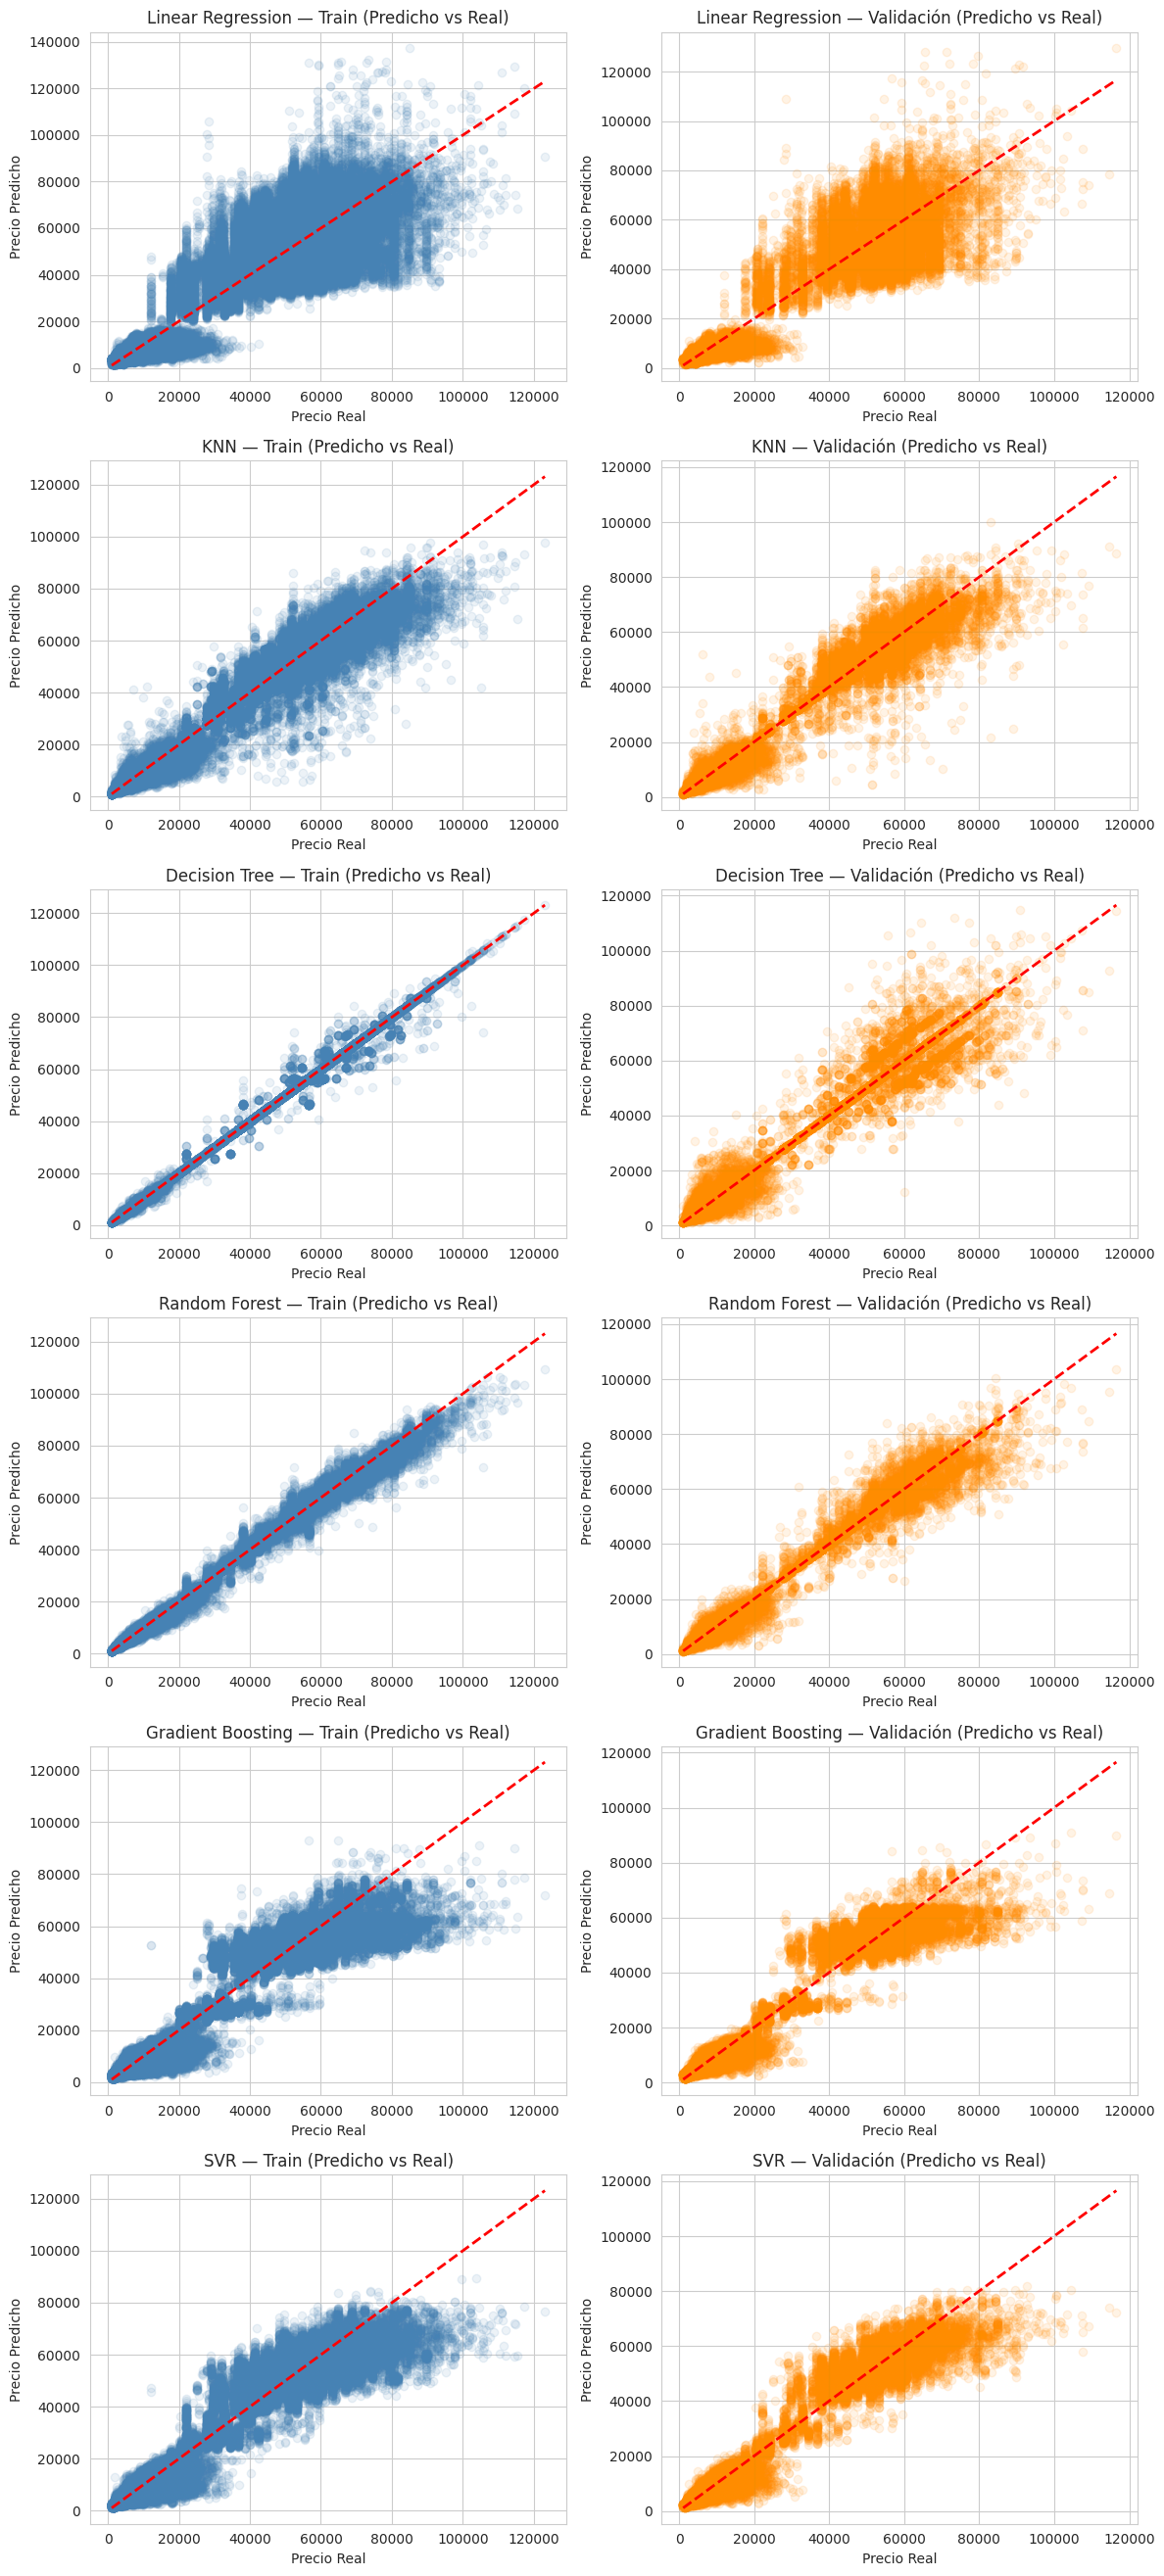

In [29]:
results_reg = []

# Grid de 5 modelos x 2 (train y val) = 5 filas, 2 columnas
n_models = len(models)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 4.4 * n_models))

for i, (name, model) in enumerate(models.items()):
    # Predicciones en escala log
    y_pred_train_log = model.predict(X_train_processed)
    y_pred_val_log = model.predict(X_val_processed)

    # Revertir a escala original (precio real) para interpretar las métricas
    y_pred_train = np.expm1(y_pred_train_log)
    y_pred_val = np.expm1(y_pred_val_log)

    # Métricas en train (sobre precio real)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    # Métricas en validación (sobre precio real)
    mae_val = mean_absolute_error(y_val, y_pred_val)
    mse_val = mean_squared_error(y_val, y_pred_val)
    r2_val = r2_score(y_val, y_pred_val)

    results_reg.append({
        'Modelo': name,
        'MAE_train': mae_train, 'MAE_val': mae_val,
        'MSE_train': mse_train, 'MSE_val': mse_val,
        'R2_train': r2_train, 'R2_val': r2_val
    })

    print(f"\n{'='*50}\nModelo: {name}\n{'='*50}")
    print(f"Train      -> MAE: {mae_train:.2f} | MSE: {mse_train:.2f} | R²: {r2_train:.3f}")
    print(f"Validation -> MAE: {mae_val:.2f} | MSE: {mse_val:.2f} | R²: {r2_val:.3f}")
    print()

    # Predicho vs Real - Train
    axes[i, 0].scatter(y_train, y_pred_train, alpha=0.1, color='steelblue')
    axes[i, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[i, 0].set_title(f'{name} — Train (Predicho vs Real)')
    axes[i, 0].set_xlabel('Precio Real')
    axes[i, 0].set_ylabel('Precio Predicho')

    # Predicho vs Real - Validación
    axes[i, 1].scatter(y_val, y_pred_val, alpha=0.1, color='darkorange')
    axes[i, 1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    axes[i, 1].set_title(f'{name} — Validación (Predicho vs Real)')
    axes[i, 1].set_xlabel('Precio Real')
    axes[i, 1].set_ylabel('Precio Predicho')

plt.tight_layout()
plt.show()

### Análisis de los modelos y errores

**Linear Regression:** En Train obtuvo MAE = 4621.94, MSE = 62,152,774 y R² = 0.879. En Validation obtuvo MAE = 4610.33, MSE = 62,189,572 y R² = 0.879  prácticamente idénticos. No hay overfitting (el modelo generaliza igual de bien/mal en ambos conjuntos), pero el error es el más alto de los 5 modelos y el R² el más bajo, lo que sugiere underfitting relativo: al ser un modelo lineal, no logra capturar bien relaciones no lineales ni interacciones entre variables (como stops × class, identificada en el EDA), quedándose corto frente a los modelos más flexibles.

**KNN:** En Train obtuvo MAE = 1534.62 y R² = 0.978. En Validation, MAE = 1948.24 y R² = 0.966. Hay una diferencia moderada entre ambos conjuntos, lo que indica un overfitting leve el modelo memoriza parcialmente los vecinos de entrenamiento, pero aun así generaliza razonablemente bien a datos nuevos.

**Decision Tree:** En Train obtuvo un MAE prácticamente nulo (50.30) y R² = 0.999, mientras que en Validation el MAE sube a 1172.77 y el R² baja a 0.977. Esta caída tan pronunciada entre Train y Validation es la señal más clara de overfitting entre los 5 modelos: el árbol memorizó casi perfectamente los datos de entrenamiento (incluyendo su ruido), en vez de aprender un patrón generalizable.

**Random Forest:** En Train obtuvo MAE = 420.62 y R² = 0.997; en Validation, MAE = 1064.83 y R² = 0.986. Presenta overfitting leve (mucho menor que Decision Tree, gracias al efecto de promediar muchos árboles vía Bagging), y es además el modelo con mejor desempeño global en Validation de los 5: menor MAE y mayor R².

**Gradient Boosting:** En Train obtuvo MAE = 2945.08 y R² = 0.949; en Validation, MAE = 2935.38 y R² = 0.950 prácticamente idénticos, sin señales de overfitting. Sin embargo, su error es notablemente más alto que el de KNN o Random Forest, lo que sugiere que, con esta configuración por defecto (pocos estimadores/profundidad limitada), el modelo aún no explota todo su potencial y podría beneficiarse de ajuste de hiperparámetros (más estimadores, mayor profundidad, learning rate más bajo).

**SVR:** En Train obtuvo MAE = 2626.47, MSE = 20,896,353.97 y R² = 0.959. En Validation,
MAE = 2637.50, MSE = 21,020,286.46 y R² = 0.959 — prácticamente idénticos entre ambos
conjuntos, sin ninguna señal de overfitting (similar a lo que ocurre con Regresión Lineal y
Gradient Boosting). En términos absolutos, SVR queda en una posición intermedia: mejor que
Regresión Lineal, pero por debajo de KNN, Decision Tree y Random Forest.

Interpretación de las métricas en el contexto de precios de vuelos

Recordando que price tiene una media de $20,889 y una desviación estándar de 22,698 (Punto 3): un MAE de 1,065 (Random Forest) significa que, en promedio, el modelo se equivoca en poco más del 5% del precio promedio de un tiquete un margen de error pequeño y útil en la práctica (por ejemplo, para un usuario decidiendo si el precio mostrado es razonable). En contraste, un MAE de 4,622 (Regresión Lineal) representa un error cercano al 22% del precio promedio, que ya empieza a ser significativo para decisiones de compra.

En cuanto a R²: valores entre 0.95 y 0.99 (KNN, Random Forest, Gradient Boosting, Decision Tree) indican que el modelo explica entre el 95% y el 99% de la variabilidad del precio un ajuste muy bueno, típico de este dataset porque class por sí sola ya separa casi perfectamente los precios (Punto 8). El R² = 0.879 de Regresión Lineal, aunque parece alto en términos absolutos, es notablemente el más bajo del grupo, confirmando que un modelo puramente lineal deja sin capturar una porción relevante de la relación entre las variables y el precio.


**Graficas de SVR**
Al observar las gráficas de Predicho vs. Real, se nota que SVR subestima sistemáticamente
los precios altos (Business, >$60,000-70,000): en ambos conjuntos, Train y Validation, los
puntos de esa zona quedan por debajo de la línea de predicción perfecta. Se probó mitigar
esta limitación aumentando la muestra de entrenamiento de 15,000 a 50,000 filas, lo que trajo una mejora modesta (MAE bajó de ~2,800 a ~2,630, R² subió
de 0.955 a 0.959), pero el patrón de subestimación en precios altos persistió. Esto sugiere
que la causa principal no es solo la cantidad de datos, sino también los hiperparámetros
por defecto del modelo (C=1.0, que define un margen relativamente tolerante), un ajuste
con  GridSearchCV (probando distintos valores de C y epsilon) podría mejorar aún más su desempeño en esa zona.

Es importante notar además que, a diferencia de los demás modelos, SVR se entrenó sobre una
muestra de Train (50,000 de 210,107 filas) en vez del conjunto completo, debido al alto
costo computacional del algoritmo con datasets grandes, esto significa que la comparación
no está en igualdad de condiciones frente a los demás modelos.




### Conclusión

**Random Forest** ofrece el mejor equilibrio entre precisión y generalización: el menor MAE en Validation ($1,064.83) junto con el R² más alto (0.986), y un overfitting mucho más
controlado que Decision Tree.

Decision Tree, aunque memoriza perfectamente el Train, es el
modelo con overfitting más severo y no debería usarse sin poda(max_depth,min_samples_leaf) o alguna forma de regularización.

Regresión Lineal, Gradient Boosting y SVR no muestran overfitting, pero por razones distintas:

* Regresión Lineal por ser demasiado
simple para el problema (underfitting)
* Gradient Boosting por estar posiblemente
subentrenado con sus hiperparámetros por defecto.
* SVR por una combinación de factores:
su configuración por defecto (C=1.0) y haber entrenado con una muestra reducida de datos (50,000 de 210,107 filas), lo que probablemente limita su capacidad de generalizar tan bien
como lo haría con el conjunto de entrenamiento completo y ajuste de hiperparámetros.

Se recomienda, como trabajo futuro, ajustar hiperparámetros de Gradient Boosting (más estimadores/mayor profundidad) y de SVR (C, epsilon, y evaluar entrenarlo con el dataset
completo) antes de una evaluación en producción, ya que ambos muestran señales de no estar
explotando todo su potencial con la configuración actual.


###Punto 20
Construya una tabla comparativa que incluya train y validación para regresión (filas: modelos, columnas:
MAE/MSE/R² en train y en val) y otra igual para clasificación (Accuracy/Precision/Recall/F1 en train y en val).


In [30]:
df_results_reg = pd.DataFrame(results_reg).set_index('Modelo')

# Reordenar columnas para que sea más legible (métrica agrupada por train/val)
df_results_reg = df_results_reg[[
    'MAE_train', 'MAE_val',
    'MSE_train', 'MSE_val',
    'R2_train', 'R2_val'
]].round(3)

print("Tabla comparativa — Regresión (Train vs. Validación)")
display(df_results_reg)

Tabla comparativa — Regresión (Train vs. Validación)


,MAE_train,MAE_val,MSE_train,MSE_val,R2_train,R2_val
Modelo,,,,,,
Linear Regression,4621.938,4610.333,6.215277e+07,6.218957e+07,0.879,0.879
KNN,1534.620,1948.244,1.133529e+07,1.748071e+07,0.978,0.966
Decision Tree,50.296,1172.773,3.266292e+05,1.205146e+07,0.999,0.977
Random Forest,420.619,1064.833,1.359983e+06,7.436053e+06,0.997,0.986
Gradient Boosting,2945.075,2935.378,2.603596e+07,2.573421e+07,0.949,0.950
SVR,2626.474,2637.503,2.089635e+07,2.102029e+07,0.959,0.959


###Punto 21
Seleccione el mejor modelo de cada problema y justifique la elección — no se limite a señalar la métrica más alta en
validación; discuta trade-offs (tiempo de entrenamiento, interpretabilidad, la señal de over/underfitting detectada en los
puntos anteriores) apoyándose en lo visto en clase sobre cada algoritmo.

### Selección del mejor modelo

Para seleccionar el mejor modelo se tuvieron en cuenta las métricas de **Validation**, la señal de overfitting/underfitting detectada en el Punto 18, el costo computacional y la interpretabilidad. En este caso, al ser un problema de negocio orientado a estimar precios (no un caso médico con FN/FP críticos), la métrica más relevante es el **MAE**, por ser directamente interpretable en la moneda del dataset y menos sensible a unos pocos errores extremos que el MSE; el **R²** se usa como medida complementaria de qué tanto explica el modelo la variabilidad total del precio.

* **Linear Regression:** obtuvo MAE = 4610.33 y R² = 0.879 en Validation, los peores resultados de los 6 modelos. No presenta overfitting (Train y Validation casi idénticos), pero sí un claro **underfitting**: su simplicidad no logra capturar relaciones no lineales como la interacción `stops` × `class` identificada en el EDA. Es el modelo más rápido de entrenar y el más interpretable (coeficientes directos), pero su error es demasiado alto para el contexto del negocio.

* **KNN:** obtuvo MAE = 1948.24 y R² = 0.966 en Validation. Presenta **overfitting leve** (diferencia moderada respecto a Train). Es fácil de entender conceptualmente ("vuelos parecidos tienen precios parecidos"), pero es más lento en inferencia con 300 mil registros, ya que debe calcular distancias contra todo el conjunto de entrenamiento en cada predicción.

* **Decision Tree:** obtuvo MAE = 1172.77 y R² = 0.977 en Validation, pero presenta el **overfitting más severo** de los 6 modelos (MAE de apenas 50 en Train frente a 1172 en Validation). Aunque es el modelo más fácil de interpretar visualmente (reglas tipo "si `class`=Business y `stops`>1, entonces..."), memorizó el ruido del entrenamiento y necesitaría poda (`max_depth`, `min_samples_leaf`) antes de poder confiar en él.

* **Random Forest:** obtuvo los mejores resultados de Validation: MAE = 1064.83 y R² = 0.986. Presenta **overfitting leve**, mucho menor que un árbol individual gracias al efecto de Bagging (promediar muchos árboles reduce la varianza sin aumentar demasiado el sesgo). Es más costoso de entrenar y menos interpretable que un único árbol, pero sigue permitiendo extraer importancia de variables (feature importance), lo cual es valioso para el análisis de negocio.

* **Gradient Boosting:** obtuvo MAE = 2935.38 y R² = 0.950 en Validation. No presenta overfitting (Train y Validation casi idénticos), pero su error es notablemente más alto que el de Random Forest o KNN con los hiperparámetros por defecto sugiere que el modelo aún no explota su potencial y necesitaría más estimadores o una tasa de aprendizaje ajustada para competir.

* **SVR:** obtuvo MAE = 2637.50 y R² = 0.959 en Validation, ubicándose en una posición intermedia. No presenta overfitting (Train y Validation prácticamente idénticos), pero las gráficas de Predicho vs. Real muestran que subestima sistemáticamente los precios altos (Business, >$60,000-70,000), tanto en Train como en Validation. A diferencia de los demás modelos, SVR se entrenó sobre una muestra de 50,000 filas (23.8% de Train) en lugar del conjunto completo, debido al alto costo computacional del algoritmo con datasets grandes — se probó ampliar la muestra desde 15,000 filas, lo que trajo una mejora modesta, pero no resolvió la subestimación en precios altos, sugiriendo que también le haría falta ajuste de hiperparámetros (`C`, `epsilon`). Es, junto con KNN, uno de los modelos con mayor costo computacional del grupo.

En esta primera evaluación, se selecciona **Random Forest como el mejor modelo**, principalmente porque combina el **menor MAE ($1,064.83, ~5% del precio promedio)** y el **mayor R² (0.986)** de los 6 modelos, con overfitting bajo y controlado (a diferencia de Decision Tree).

KNN generaliza de forma comparable pero con un error casi el doble y peor tiempo de inferencia a esta escala (300,153 filas)

SVR, con un R² similar al de Gradient Boosting (0.959 vs. 0.950), tampoco se acerca a Random Forest, y fue además el único modelo que no pudo entrenarse con el conjunto completo de Train por su costo computacional, el cual puede resultar una limitación práctica adicional frente a los modelos de árboles, que sí escalan bien con 210,107 filas.

Sin embargo, Gradient Boosting y SVR podrían mejorar con **ajuste de hiperparámetros**
(estimadores/profundidad/learning rate en el primero; C/epsilon en el segundo, además de entrenar con un mayor numero de datos o con el dataset completo), ambos podrían llegar a
superar a Random Forest en una etapa posterior, por lo que esta selección debe considerarse
preliminar hasta completar la validación cruzada y la evaluación final en Test.

# **Fase 6 — Evaluación final en el conjunto de Test**


###Punto 22
Evalúe TODOS los modelos de regresión entrenados sobre el conjunto de test, usando las
mismas métricas calculadas en la Fase 5.


Modelo: Linear Regression
Test -> MAE: 4619.54 | MSE: 62748149.30 | R²: 0.878

Modelo: KNN
Test -> MAE: 1959.09 | MSE: 17997713.14 | R²: 0.965

Modelo: Decision Tree
Test -> MAE: 1179.34 | MSE: 12370811.38 | R²: 0.976

Modelo: Random Forest
Test -> MAE: 1066.72 | MSE: 7593570.92 | R²: 0.985

Modelo: Gradient Boosting
Test -> MAE: 2956.50 | MSE: 26512354.36 | R²: 0.948

Modelo: SVR
Test -> MAE: 2646.72 | MSE: 21409067.23 | R²: 0.958


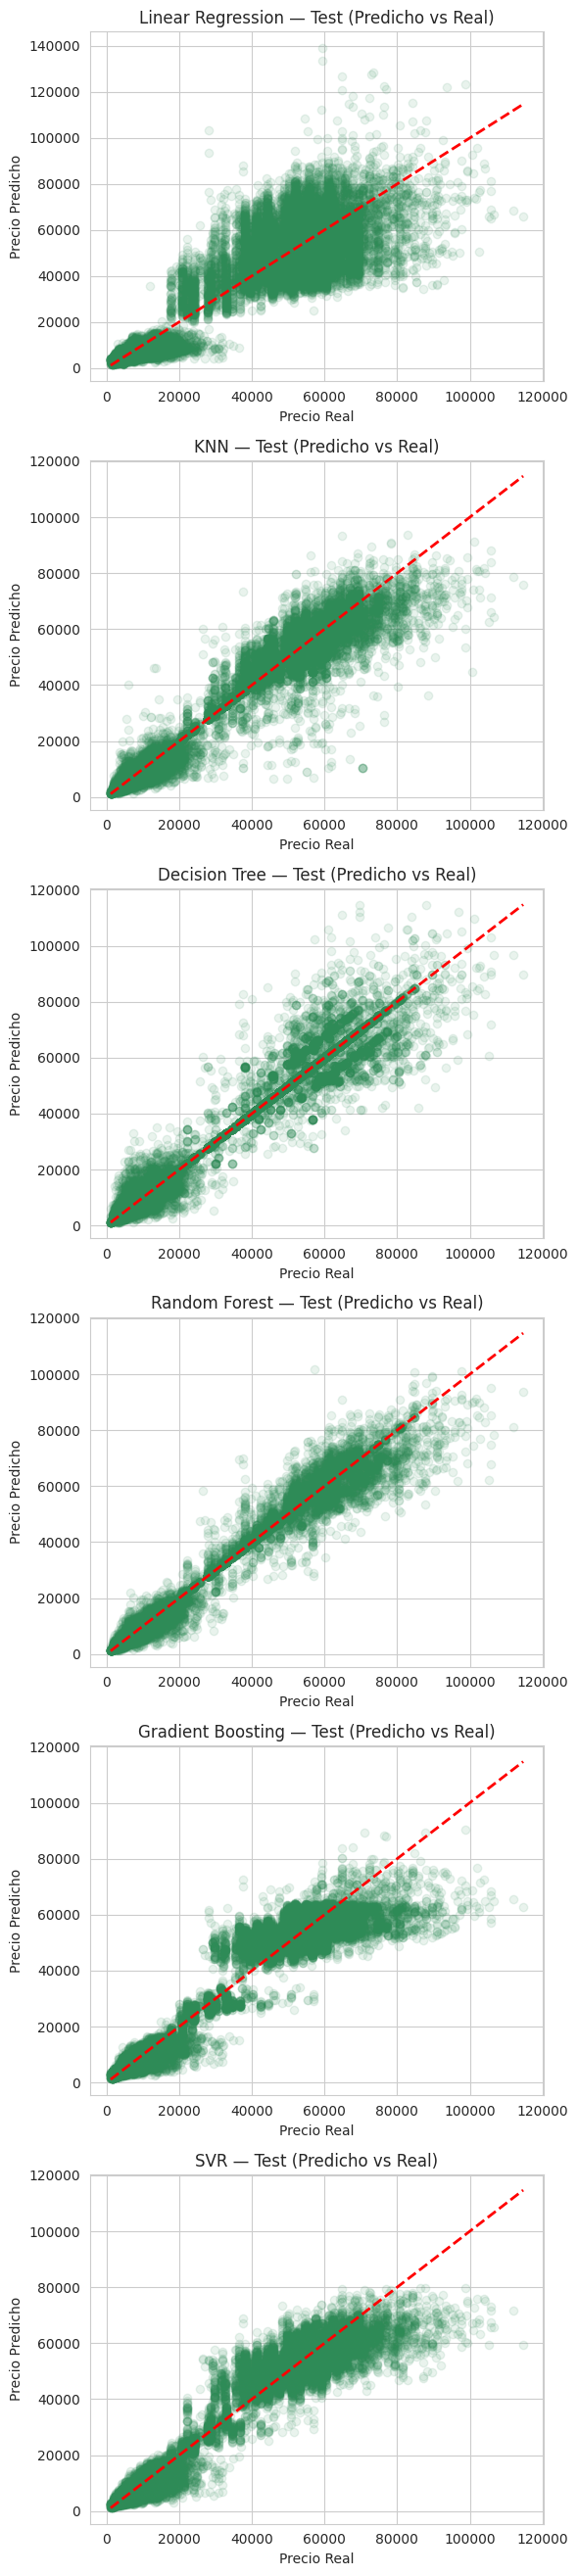


Tabla de resultados en TEST (Regresión):


,MAE_test,MSE_test,R2_test
Modelo,,,
Linear Regression,4619.542,6.274815e+07,0.878
KNN,1959.092,1.799771e+07,0.965
Decision Tree,1179.340,1.237081e+07,0.976
Random Forest,1066.723,7.593571e+06,0.985
Gradient Boosting,2956.505,2.651235e+07,0.948
SVR,2646.721,2.140907e+07,0.958


In [32]:
results_test_reg = []

n_models = len(models)
fig, axes = plt.subplots(n_models, 1, figsize=(6, 4.4 * n_models))

for i, (name, model) in enumerate(models.items()):
    # Predicciones en escala log, revertidas a precio real
    y_pred_test_log = model.predict(X_test_processed)
    y_pred_test = np.expm1(y_pred_test_log)

    mae_test = mean_absolute_error(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    results_test_reg.append({
        'Modelo': name,
        'MAE_test': mae_test,
        'MSE_test': mse_test,
        'R2_test': r2_test
    })

    print(f"\n{'='*50}\nModelo: {name}\n{'='*50}")
    print(f"Test -> MAE: {mae_test:.2f} | MSE: {mse_test:.2f} | R²: {r2_test:.3f}")

    axes[i].scatter(y_test, y_pred_test, alpha=0.1, color='seagreen')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_title(f'{name} — Test (Predicho vs Real)')
    axes[i].set_xlabel('Precio Real')
    axes[i].set_ylabel('Precio Predicho')

plt.tight_layout()
plt.show()

df_results_test_reg = pd.DataFrame(results_test_reg).set_index('Modelo').round(3)
print("\nTabla de resultados en TEST (Regresión):")
display(df_results_test_reg)

###Punto 23

Construya una tabla comparativa final con los resultados en test para cada problema, y compárela contra la tabla de
validación de la Fase 5: ¿el orden/ranking de los modelos se mantiene igual? ¿las métricas del mejor modelo en test son
consistentes con las que obtuvo en validación, o hay una diferencia importante? Interprete qué significaría una
diferencia grande entre val y test.

In [33]:
# Columnas de validación ya calculadas en la Fase 5 (df_results_reg)
df_val_only_reg = df_results_reg[['MAE_val', 'MSE_val', 'R2_val']]

# Se unen con las columnas de test (Punto 22)
df_val_vs_test_reg = df_val_only_reg.join(df_results_test_reg)

# Reordenar para que quede MAE_val, MAE_test, MSE_val, MSE_test, R2_val, R2_test
df_val_vs_test_reg = df_val_vs_test_reg[[
    'MAE_val', 'MAE_test',
    'MSE_val', 'MSE_test',
    'R2_val', 'R2_test'
]]

print("Tabla comparativa final — Validación vs. Test (Regresión)")
display(df_val_vs_test_reg.round(3))

# Diferencia (Val - Test): valores grandes en valor absoluto son señal de alerta
df_diff_reg = pd.DataFrame({
    'Diff_MAE': df_val_vs_test_reg['MAE_val'] - df_val_vs_test_reg['MAE_test'],
    'Diff_MSE': df_val_vs_test_reg['MSE_val'] - df_val_vs_test_reg['MSE_test'],
    'Diff_R2':  df_val_vs_test_reg['R2_val']  - df_val_vs_test_reg['R2_test'],
})
print("\nDiferencia (Validación - Test) por modelo:")
display(df_diff_reg.round(4))

Tabla comparativa final — Validación vs. Test (Regresión)


,MAE_val,MAE_test,MSE_val,MSE_test,R2_val,R2_test
Modelo,,,,,,
Linear Regression,4610.333,4619.542,6.218957e+07,6.274815e+07,0.879,0.878
KNN,1948.244,1959.092,1.748071e+07,1.799771e+07,0.966,0.965
Decision Tree,1172.773,1179.340,1.205146e+07,1.237081e+07,0.977,0.976
Random Forest,1064.833,1066.723,7.436053e+06,7.593571e+06,0.986,0.985
Gradient Boosting,2935.378,2956.505,2.573421e+07,2.651235e+07,0.950,0.948
SVR,2637.503,2646.721,2.102029e+07,2.140907e+07,0.959,0.958



Diferencia (Validación - Test) por modelo:


,Diff_MAE,Diff_MSE,Diff_R2
Modelo,,,
Linear Regression,-9.209,-558577.596,0.001
KNN,-10.848,-516999.756,0.001
Decision Tree,-6.567,-319349.912,0.001
Random Forest,-1.890,-157518.289,0.001
Gradient Boosting,-21.127,-778146.614,0.002
SVR,-9.218,-388780.776,0.001


Al comparar los resultados de Validación y Test, se puede ver si los modelos realmente generalizan bien a datos nuevos.

**1. ¿Se mantiene el mismo ranking?**

Sí. En Validación se había elegido Random Forest porque tenía el menor MAE y el mayor R² del grupo. En Test, el ranking se mantiene exactamente igual:

- Random Forest: mantiene el mejor MAE (1064.83 → 1066.72) y el mejor R² (0.986 → 0.985).
- Decision Tree: se mantiene en segundo lugar (MAE 1172.77 → 1179.34).
- KNN: se mantiene en tercer lugar (MAE 1948.24 → 1959.09).
- SVR: se mantiene en cuarto lugar (MAE 2637.50 → 2646.72).
- Gradient Boosting: se mantiene en quinto lugar (MAE 2935.38 → 2956.50).
- Linear Regression: se mantiene en último lugar (MAE 4610.33 → 4619.54).


**2. ¿Los resultados son consistentes?**

Sí. Todos los modelos muestran diferencias mínimas entre Validación y Test:

- Random Forest: MAE prácticamente igual (diferencia de 1.89), R² igual (0.986 vs 0.985).
- Decision Tree: MAE casi igual (diferencia de 6.57), R² igual (0.977 vs 0.976).
- KNN: MAE casi igual (diferencia de 10.85), R² igual (0.966 vs 0.965).
- SVR: MAE casi igual (diferencia de 9.22), R² prácticamente idéntico (0.959 vs 0.958).
- Gradient Boosting: MAE casi igual (diferencia de 21.12), R² igual (0.950 vs 0.948).
- Linear Regression: MAE casi igual (diferencia de $9.21), R² prácticamente idéntico (0.879 vs 0.878).



**3. ¿Qué significa una diferencia grande entre Validación y Test?**

Una diferencia importante indicaría que el conjunto de Validación no era representativo, que hubo cierto ajuste indirecto al conjunto de Validación (por ejemplo, al comparar varios modelos y elegir el mejor mirando solo esa partición), o simplemente variabilidad por el tamaño de los datos. En este caso, **no se observa ninguna diferencia grande** — algo esperable dado que el dataset tiene 300,153 filas, lo que hace que tanto Validación como Test sean muestras suficientemente grandes y representativas de la misma distribución de precios.

Los resultados de Test confirman a **Random Forest** como el mejor modelo, con el menor error (MAE≈$1,067) y el mayor poder explicativo (R²≈0.985), consistente con lo observado en Validación. A diferencia de Gradient Boosting, Decision Tree o SVR, Random Forest generaliza de forma estable sin señales de que su buen desempeño en Validación fuera producto del azar de esa partición específica. Esto da confianza para recomendarlo como el modelo final, dejando como trabajo futuro el ajuste de hiperparámetros de Gradient Boosting y de SVR (además de evaluar entrenar este último con el conjunto de Train completo), que siguen mostrando el mayor margen de mejora del grupo.

# **Fase 7 — Cross Validation**


##Punto 24

Investigue y explique con sus propias palabras qué es la validación cruzada (K-Fold Cross Validation), cómo funciona
y por qué puede dar una estimación más confiable del desempeño de un modelo que un único split de train/validation.


### Validación Cruzada (K-Fold Cross Validation)

La **validación cruzada K-Fold** es una técnica que permite evaluar un modelo de forma más confiable que un único split de Train y Validation. Consiste en dividir los datos en **K grupos (folds)** y entrenar y validar el modelo varias veces.

Por ejemplo, con **K = 5**, los datos se dividen en 5 partes. En cada iteración se utilizan 4 partes para entrenar y 1 para validar. Esto se repite hasta que cada parte haya sido utilizada una vez como validación. Al final se calcula el **promedio y la desviación estándar** de las métricas obtenidas.

Esta técnica es útil porque:

* **Reduce la dependencia de un solo split:** evita que el resultado dependa demasiado de qué vuelos específicos quedaron en Train o Validation por azar.
* **Aprovecha mejor los datos:** cada registro se utiliza K-1 veces para entrenar y una vez para validar.
* **Mide la estabilidad del modelo:** una desviación estándar baja indica que el modelo tiene resultados similares en diferentes particiones, mientras que una alta indica mayor variabilidad.
* **Da una estimación más robusta:** aunque el split de Validación de la Fase 5 ya es grande (~45,000 vuelos, de un dataset de 300,153 registros), sigue siendo una sola "muestra" del desempeño. K-Fold promedia varias particiones distintas, reduciendo el riesgo de que una partición particularmente fácil o difícil distorsione la conclusión.

Un único split proporciona una sola visión del rendimiento del modelo, mientras que **K-Fold permite obtener varias evaluaciones y promediarlas**, dando un resultado más estable y representativo de cómo se comportaría el modelo con vuelos nuevos.


###Punto 25

Implemente K-Fold Cross Validation sobre el mejor modelo encontrado para el problema de regresión, usando las
métricas relevantes.

In [34]:
# Seleccionar automáticamente el mejor modelo según MAE en validación (Fase 5)
best_model_name_reg = df_results_reg['MAE_val'].idxmin()
best_model_reg = models[best_model_name_reg]

print(f"Mejor modelo de regresión (según MAE en validación): {best_model_name_reg}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores, mse_scores, r2_scores = [], [], []

for train_idx, val_idx in kf.split(X_train_processed):
    X_fold_train = X_train_processed[train_idx]
    X_fold_val = X_train_processed[val_idx]
    y_fold_train_log = y_train_log.iloc[train_idx]
    y_fold_val_real = y_train.iloc[val_idx]  # precio real, sin transformar

    model_fold = clone(best_model_reg)
    model_fold.fit(X_fold_train, y_fold_train_log)

    y_pred_fold_log = model_fold.predict(X_fold_val)
    y_pred_fold = np.expm1(y_pred_fold_log)  # volver a escala real de precio

    mae_scores.append(mean_absolute_error(y_fold_val_real, y_pred_fold))
    mse_scores.append(mean_squared_error(y_fold_val_real, y_pred_fold))
    r2_scores.append(r2_score(y_fold_val_real, y_pred_fold))

mae_scores = np.array(mae_scores)
mse_scores = np.array(mse_scores)
r2_scores = np.array(r2_scores)

print(f"\n{'='*55}\nK-Fold Cross Validation (K=5) — {best_model_name_reg}\n(métricas en escala real de precio)\n{'='*55}")
print(f"MAE -> Media: {mae_scores.mean():.2f} | Desv. Estándar: {mae_scores.std():.2f} | Folds: {np.round(mae_scores, 2)}")
print(f"MSE -> Media: {mse_scores.mean():.2f} | Desv. Estándar: {mse_scores.std():.2f} | Folds: {np.round(mse_scores, 2)}")
print(f"R²  -> Media: {r2_scores.mean():.3f} | Desv. Estándar: {r2_scores.std():.3f} | Folds: {np.round(r2_scores, 3)}")

Mejor modelo de regresión (según MAE en validación): Random Forest

K-Fold Cross Validation (K=5) — Random Forest
(métricas en escala real de precio)
MAE -> Media: 1099.94 | Desv. Estándar: 11.70 | Folds: [1107.41 1119.3  1093.6  1090.93 1088.44]
MSE -> Media: 7697173.96 | Desv. Estándar: 190264.69 | Folds: [7862366.32 7946791.48 7708627.97 7498605.48 7469478.54]
R²  -> Media: 0.985 | Desv. Estándar: 0.000 | Folds: [0.985 0.985 0.985 0.985 0.986]


###Punto 27

 Compare los resultados de cross validation contra el desempeño obtenido en el conjunto de validación original de la
Fase 5: ¿el desempeño mejora, empeora o se mantiene similar? ¿La desviación estándar entre folds sugiere que el
modelo es estable o sensible a qué datos recibe? Interprete.


In [35]:
val_metrics_best_reg = df_results_reg.loc[best_model_name_reg, ['MAE_val', 'MSE_val', 'R2_val']]

print(f"Comparación — {best_model_name_reg}")
print(f"\n{'Métrica':<12}{'Val (Fase 5)':<15}{'CV Media':<12}{'CV Std':<10}")
print(f"{'MAE':<12}{val_metrics_best_reg['MAE_val']:<15.2f}{mae_scores.mean():<12.2f}{mae_scores.std():<10.2f}")
print(f"{'MSE':<12}{val_metrics_best_reg['MSE_val']:<15.2f}{mse_scores.mean():<12.2f}{mse_scores.std():<10.2f}")
print(f"{'R2':<12}{val_metrics_best_reg['R2_val']:<15.3f}{r2_scores.mean():<12.3f}{r2_scores.std():<10.3f}")

Comparación — Random Forest

Métrica     Val (Fase 5)   CV Media    CV Std    
MAE         1064.83        1099.94     11.70     
MSE         7436052.63     7697173.96  190264.69 
R2          0.986          0.985       0.000     


**1. ¿El desempeño mejora, empeora o se mantiene similar?**

Se mantiene prácticamente igual, con una leve subida en el error. El MAE promedio de Cross Validation (1099.94) es apenas un 3.3% más alto que el MAE de Validación de la Fase 5 (1064.83) — una diferencia de 35, insignificante en el contexto de precios de vuelos que van desde unos pocos miles hasta más de $100,000. El R² se mantiene prácticamente idéntico (0.986 vs. 0.985).

**2. ¿Qué indica la desviación estándar entre folds?**

La desviación estándar es muy baja en las tres métricas: 11.70 en MAE (menos del 1% de la media), y 0.000 en R² (los 5 folds dieron 0.985 o 0.986, sin ninguna variación relevante). Esto indica que Random Forest es un modelo **estable**: su desempeño no depende de qué subconjunto específico de vuelos reciba para entrenar, sino que generaliza de forma consistente sin importar la partición de los datos.

**3. Conclusión**

La validación cruzada confirma la estabilidad de Random Forest como el mejor modelo de regresión. La pequeña diferencia entre el MAE de Validación (1064.83) y el de Cross Validation (1099.94) es esperable: la Fase 5 evaluó el modelo en un único split de validación, mientras que Cross Validation promedia 5 particiones distintas de Train, dando una estimación más conservadora y realista de cómo se comportaría el modelo con datos nuevos. La desviación estándar prácticamente nula refuerza la confianza en Random Forest como modelo final: su buen desempeño no fue un resultado afortunado de una partición específica, sino un comportamiento reproducible.

# **Fase 8 — Conclusiones**

## Conclusiones Generales del Estudio

### 1. Desempeño y selección del modelo

El estudio se enfocó en predecir el **precio de un tiquete de vuelo** a partir de características como aerolínea, ciudades de origen/destino, horarios, escalas, clase y anticipación de compra. Al ser una variable numérica continua, se priorizó el **MAE** como métrica principal, por ser directamente interpretable en la moneda del dataset y menos
sensible a errores puntuales extremos que el MSE; el **R²** se usó como medida complementaria de qué tanto explica el modelo la variabilidad total del precio.

En el conjunto de **Test**:

* **Random Forest** obtuvo el mejor desempeño: MAE = 1066.72 y R² = 0.985, consistente con
  Validación (MAE = 1064.83, R² = 0.986) y confirmado además por Cross Validation (MAE = promedio = 1099.94, Std = 11.70).
  Presenta overfitting leve y bien controlado gracias al efecto de Bagging.
* **Decision Tree** obtuvo MAE = 1179.34 y R² = 0.976, con la señal de overfitting más marcada del grupo (en Train su MAE era prácticamente nulo: 50.30).
* **KNN** obtuvo MAE = 1959.09 y R² = 0.965, con overfitting leve.
* **SVR** obtuvo MAE = 2646.72 y R² = 0.958, sin señales de overfitting, pero mostrando una subestimación sistemática de los precios altos (Business) tanto en Train como en Validación/Test. Se entrenó sobre una muestra de 50,000 filas por el alto costo computacional del algoritmo con datasets grandes, lo cual limita la comparación directa con los demás modelos.
* **Gradient Boosting** obtuvo MAE = 2956.50 y R² = 0.948, sin señales relevantes de overfitting (Train y Validation casi idénticos), pero con un error notablemente más alto que KNN o Random Forest — indicio de que, con sus hiperparámetros por defecto, el modelo no explota todo su potencial.
* **Linear Regression** obtuvo el peor resultado: MAE = 4619.54 y R² = 0.878, señal clara de **underfitting**: su simplicidad no logra capturar relaciones no lineales como la interacción `stops` × `class` identificada en el EDA (Punto 8).

Por lo tanto, se selecciona **Random Forest** como modelo final: ofrece el menor error, el mayor R², un overfitting controlado y un desempeño estable confirmado por Cross Validation, sin depender de una sola partición afortunada de los datos.

### 2. Preprocesamiento

El preprocesamiento fue determinante para obtener resultados confiables:

* No se encontraron registros duplicados (0 de 300,153 filas), por lo que el dataset se mantuvo íntegro.
* Se utilizaron diferentes técnicas de codificación según el tipo de variable: **binaria** para `class`, **Ordinal Encoding** para `stops`, `departure_time` y `arrival_time` (por su orden natural), y **One-Hot Encoding** para `airline`, `source_city` y `destination_city` (variables nominales de baja cardinalidad). La variable `flight` (1,561 valores únicos) se descartó por su altísima cardinalidad y su nulo poder de generalización.
* Se aplicó **StandardScaler** a `days_left` (sin outliers) y **RobustScaler** a `duration`(con outliers conservados por tener explicación de negocio válida: vuelos con múltiples escalas).
* Se aplicó una **transformación logarítmica a `price`** (la variable objetivo) para reducir su fuerte sesgo bimodal (Economy vs. Business), especialmente relevante para los modelos lineales y de distancia, y necesaria en particular para SVR (cuyo hiperparámetro `epsilon`, el ancho del tubo de tolerancia, solo tiene sentido en una escala comprimida).

### 3. Limitaciones

El estudio no realizó ajuste de hiperparámetros (GridSearchCV) sobre los 6 modelos, lo cual limita especialmente a Gradient Boosting y SVR, que mostraron el mayor margen de mejora del grupo con su configuración por defecto. Adicionalmente, SVR se entrenó sobre una muestra de Train (50,000 de 210,107 filas) en vez del conjunto completo, debido al alto costo
computacional del algoritmo. Se probó aumentar la muestra desde 15,000 filas, lo que trajo una mejora modesta pero no resolvió su subestimación sistemática de los precios altos. Además, el dataset corresponde a un mercado y período específico (vuelos domésticos en India), por lo que el modelo podría no generalizar directamente a otras rutas o épocas del
año con patrones de precio distintos. Tampoco se exploraron interacciones explícitas entre variables (como `stops` × `class`) en un modelo lineal regularizado (Ridge/Lasso), lo que podría cerrar parte de la brecha con los modelos de árboles sin sacrificar tanta interpretabilidad.

### 4. Trabajo futuro

Como próximos pasos se propone:

* Realizar ajuste de hiperparámetros, especialmente para Gradient Boosting (más estimadores, menor learning rate) y SVR (C, epsilon).
* Evaluar entrenar SVR con el conjunto completo de Train si se dispone de mayor capacidad computacional, para determinar si su desempeño mejora sustancialmente.
* Explorar interacciones y nuevas características derivadas (por ejemplo, combinar `stops` y `class`).
* Mejorar la interpretabilidad del modelo ganador utilizando herramientas como SHAP, para entender qué variables mueven más el precio.
* Validar el modelo con datos de otro período o mercado para evaluar su capacidad de generalización real.

### Conclusión final

Random Forest ofrece el mejor equilibrio entre precisión, generalización y estabilidad para predecir el precio de vuelos en este dataset: el menor MAE en Test ($1,066.72), el R² más alto (0.985), y una desviación estándar prácticamente nula entre folds de Cross Validation confirman que su buen desempeño no fue producto del azar de una partición específica. De los 6 modelos evaluados, ninguno logró superarlo, aunque Gradient Boosting y SVR muestran el mayor potencial de mejora si se realiza ajuste de hiperparámetros, aunque también hay que considerar la limitante adicional del SVR por su alto costo computacional en datasets grandes. Se recomienda Random Forest como modelo final, dejando como trabajo futuro la exploración de esas dos alternativas.

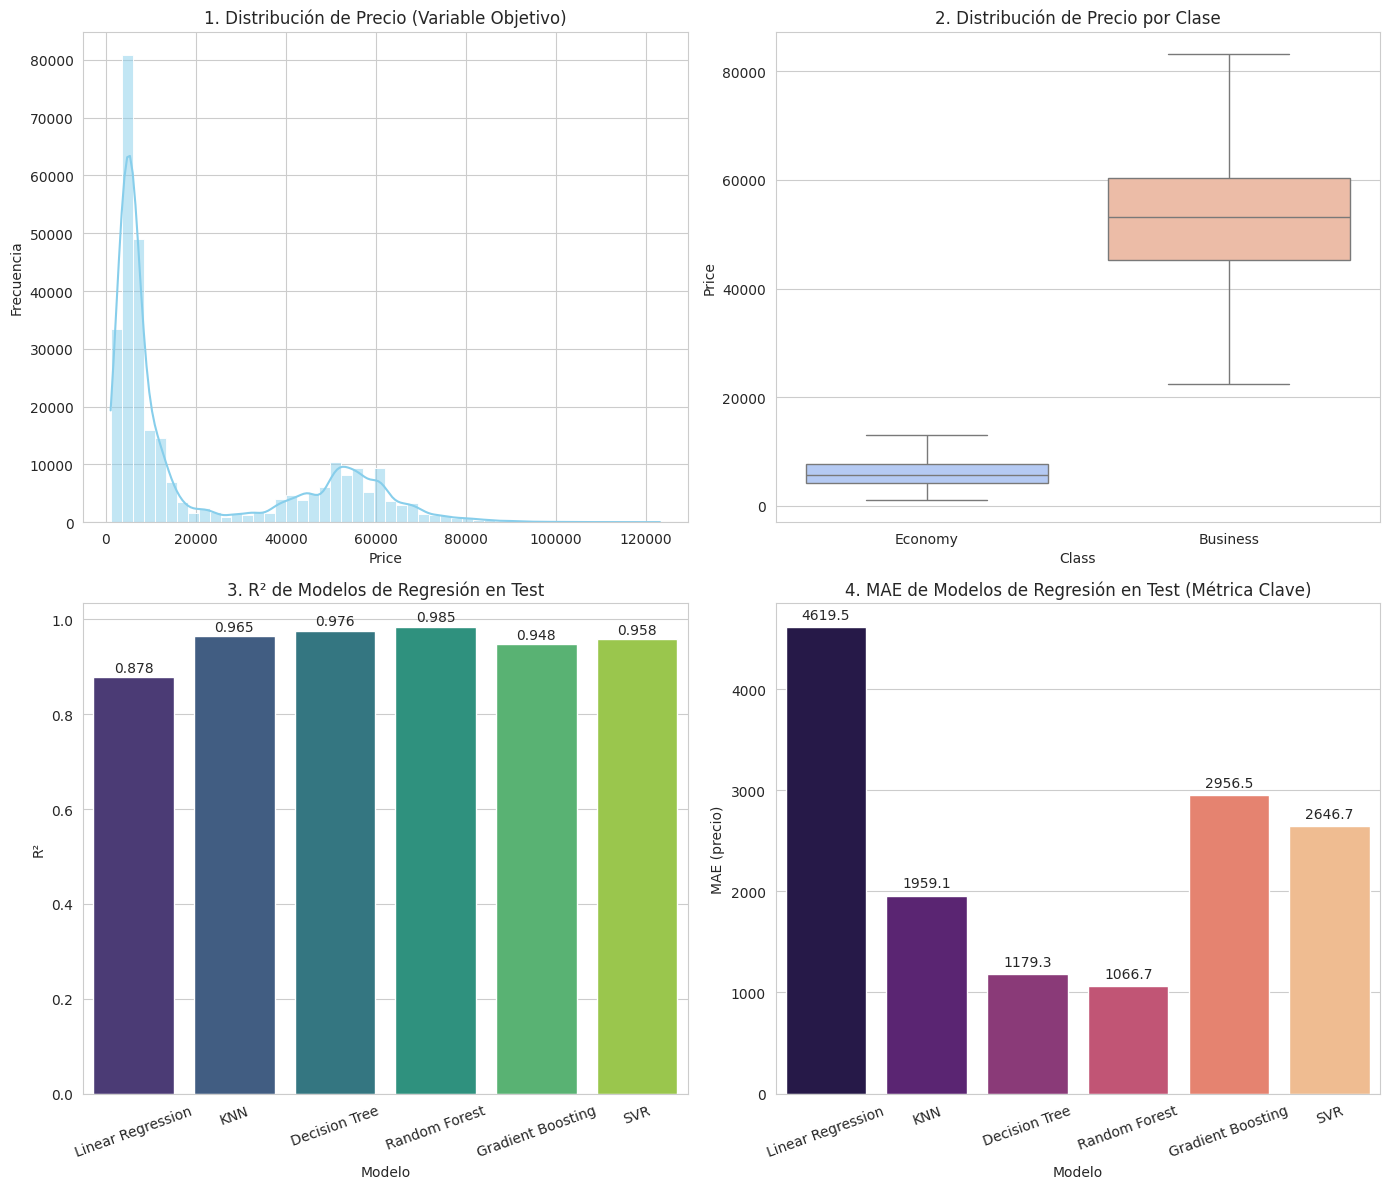

In [36]:
# Configuración de plots
sns.set_style("whitegrid")

# Creación del subplot 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Gráfico 1: Distribución de la variable objetivo 'price' (desde EDA)
sns.histplot(df_cleaned['price'], kde=True, bins=50, color='skyblue', ax=axes[0])
axes[0].set_title('1. Distribución de Precio (Variable Objetivo)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Distribución de Precio por Clase (desde EDA)
sns.boxplot(x='class', y='price', hue='class', data=df_cleaned, palette='coolwarm',
            legend=False, showfliers=False, ax=axes[1])
axes[1].set_title('2. Distribución de Precio por Clase')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Price')

# Gráfico 3: Comparación del R² en Test para Modelos de Regresión
models_r2_test = df_results_test_reg['R2_test']
sns.barplot(x=models_r2_test.index, y=models_r2_test.values, hue=models_r2_test.index,
            palette='viridis', legend=False, ax=axes[2])
axes[2].set_title('3. R² de Modelos de Regresión en Test')
axes[2].set_xlabel('Modelo')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=20)
for index, value in enumerate(models_r2_test.values):
    axes[2].text(index, value + 0.005, str(round(value, 3)), ha='center', va='bottom')

# Gráfico 4: Comparación del MAE en Test para Modelos de Regresión
models_mae_test = df_results_test_reg['MAE_test']
sns.barplot(x=models_mae_test.index, y=models_mae_test.values, hue=models_mae_test.index,
            palette='magma', legend=False, ax=axes[3])
axes[3].set_title('4. MAE de Modelos de Regresión en Test (Métrica Clave)')
axes[3].set_xlabel('Modelo')
axes[3].set_ylabel('MAE (precio)')
axes[3].tick_params(axis='x', rotation=20)
for index, value in enumerate(models_mae_test.values):
    axes[3].text(index, value + 50, str(round(value, 1)), ha='center', va='bottom')

plt.tight_layout()
plt.show()